# END-TO-END SUPPLY CHAIN PERFORMANCE ANALYTICS

End-to-end analysis of vendor profitability, procurement logistics, sales seasonality,
store/city performance, and inventory integrity, built on the 4 SQL summary tables and
raw `sales`/`purchases` tables in the MySQL database (built by `ingestion_db.py` and
`build_summary_tables.py`). All data is pulled directly from the database.

**Sections:**
1. Vendor-Product Sales Summary: profitability, margins, stock-flow ratio
2. Procurement & Logistics Summary: freight efficiency, lead times, payment behavior
3. Time-Series Analysis: seasonality, trends, promotions
4. Store & City Performance: geographic angle
5. Inventory Reconciliation: stockouts, dead stock, shrinkage, new/discontinued SKUs
6. Dead-Stock Analysis: purchased-but-never-sold products
7. Executive Summary & Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Loading the dataset

In [2]:
# Creating database connection
load_dotenv()

DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_product_sales_summary", engine)
df.head()

,VendorNumber,VendorName,ProductID,ProductName,PurchasePrice,CatalogPrice,Volume,Classification,BottleSizeCategory,TotalPurchaseQuantity,...,FreightCost,IsDeadStock,IsFreeSample,PromoSalesQuantity,HasPromoSales,AvgSellingPrice,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,2,Standard,8,...,27.08,0,0,0,0,36.99,474.94,71.33,2.2500,3.4882
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162,2,Standard,320,...,27.08,0,0,0,0,24.99,-4840.24,-807.03,0.0750,0.1103
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750,1,Bulk,1,...,0.48,1,0,0,0,NaN,-105.07,NaN,0.0000,0.0000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750,1,Standard,39,...,367.52,0,0,0,0,14.99,258.37,36.67,1.2051,1.5791
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750,1,Large,6,...,367.52,1,0,0,0,NaN,-66.60,NaN,0.0000,0.0000


In [3]:
def format_dollars(value):
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.2f}M"
    elif abs(value) >= 1_000:
        return f"${value / 1_000:.2f}K"
    else:
        return f"${value:.2f}"

# 1. Vendor-Product Sales Summary

Grain: one row per (VendorNumber, ProductID)

## 1.0 Exploratory Data Analysis

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10693.0,10649.892921,18752.805318,2.00,3951.0000,7153.0000,9552.000000,2.013590e+05
ProductID,10693.0,18037.744319,12662.525384,58.00,5789.0000,18761.0000,25514.000000,9.063100e+04
PurchasePrice,10693.0,24.383023,109.264519,0.00,6.8400,10.4500,19.470000,5.681810e+03
CatalogPrice,10693.0,35.640338,148.239484,0.00,10.9900,15.9900,28.990000,7.499990e+03
Volume,10693.0,847.351351,664.278909,50.00,750.0000,750.0000,750.000000,2.000000e+04
Classification,10693.0,1.703825,0.456591,1.00,1.0000,2.0000,2.000000,2.000000e+00
TotalPurchaseQuantity,10693.0,3140.781539,11094.573249,1.00,36.0000,262.0000,1978.000000,3.376600e+05
TotalPurchaseDollars,10693.0,30103.877820,123062.388765,0.00,453.1800,3655.2300,20733.420000,3.811252e+06
TotalSalesQuantity,10693.0,3077.375666,10952.350246,0.00,33.0000,261.0000,1929.000000,3.349390e+05
TotalSalesDollars,10693.0,42244.678463,167648.388405,0.00,729.2700,5298.2100,28406.050000,5.101920e+06


**Note:** `FreightCost` in the table above is a vendor-level total repeated on every product row of that vendor, so its
row-level statistics here are not meaningful. Freight is analysed at vendor level (Section 1.13) and at purchase-order
level (Section 2). Likewise, `ProfitMargin` has extreme row-level values (minimum below -23,000%) caused by a few
low-sales rows, so its plain average is not a reliable measure of profitability. Sales-weighted margins are used for
all segment comparisons below.

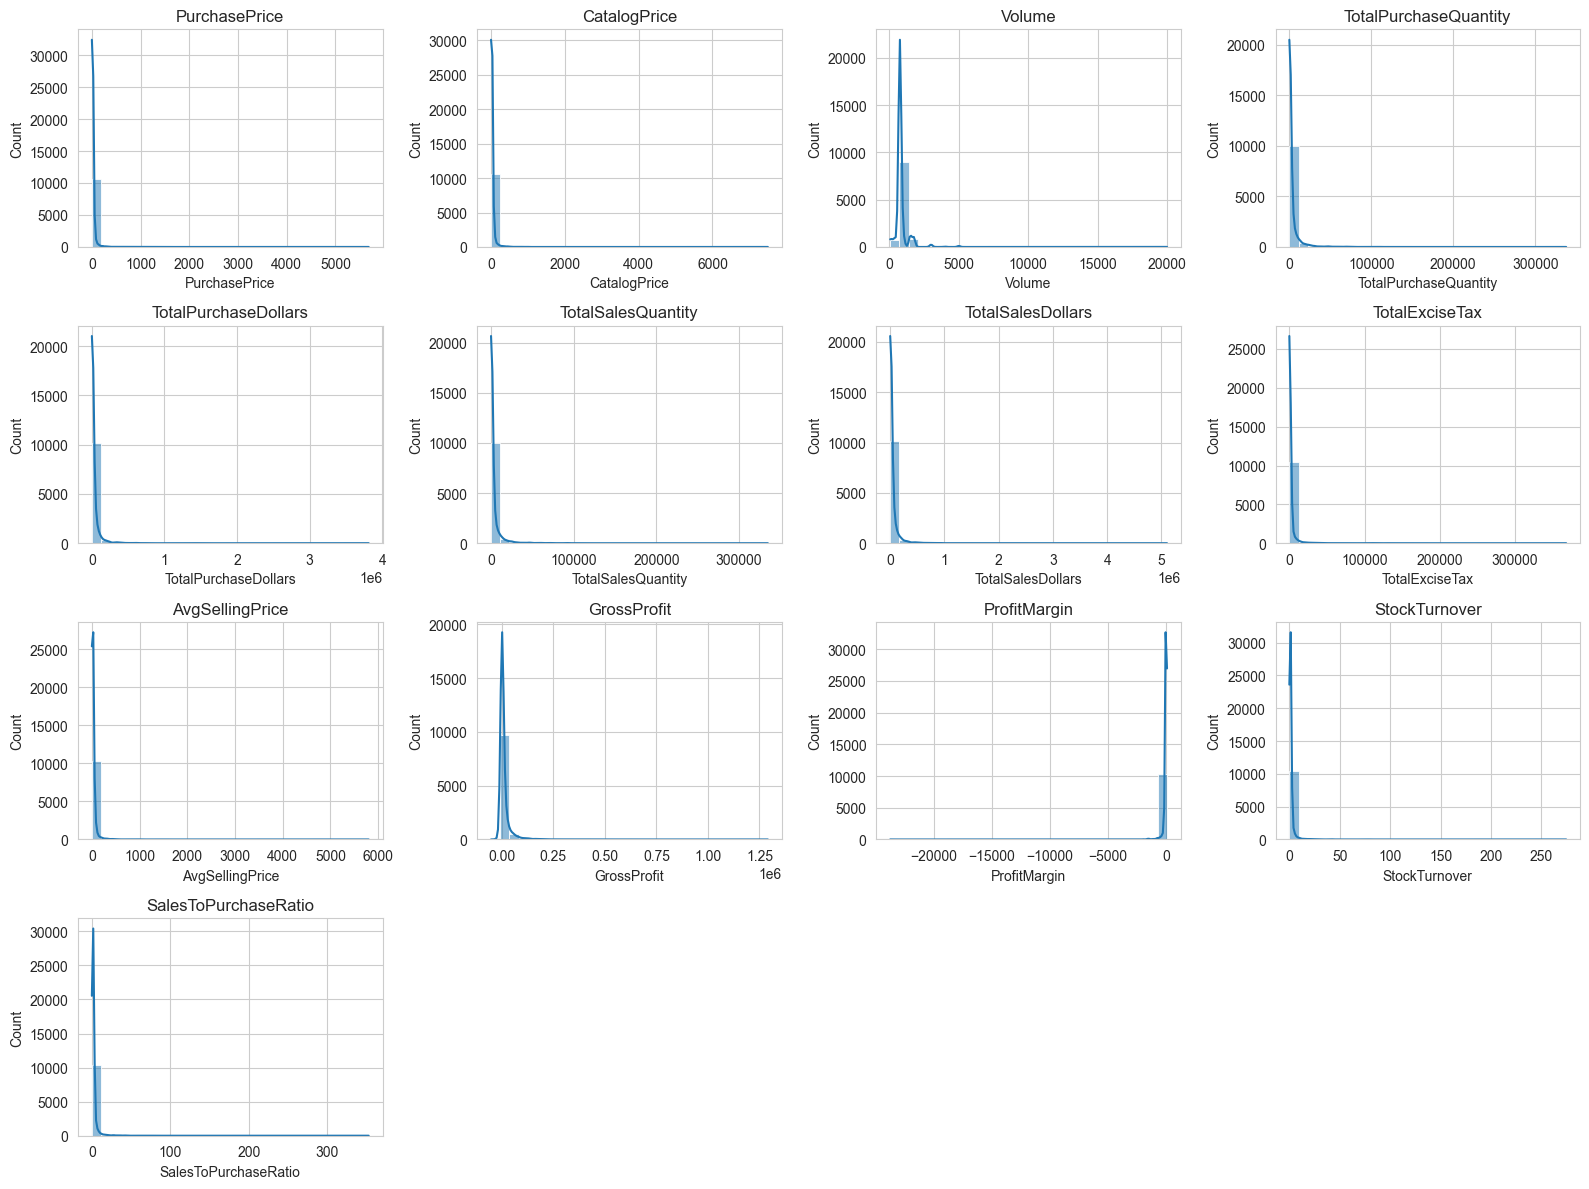

In [5]:
# Distribution plots - meaningful numeric columns only. IDs (VendorNumber, ProductID) and
# binary flags (IsDeadStock, IsFreeSample, HasPromoSales) are excluded: a histogram of an ID
# or a 0/1 flag isn't informative, they're covered as counts/rates elsewhere in this section.
# FreightCost is also excluded: it is a vendor-level total repeated on every product row of that
# vendor, so plotting/correlating it per product would over-weight vendors with big catalogs.
# Freight is analysed correctly at vendor level in Section 1.13 and at PO level in Section 2.
numerical_cols = ['PurchasePrice', 'CatalogPrice', 'Volume', 'TotalPurchaseQuantity',
                   'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
                   'TotalExciseTax', 'AvgSellingPrice', 'GrossProfit',
                   'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']

plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

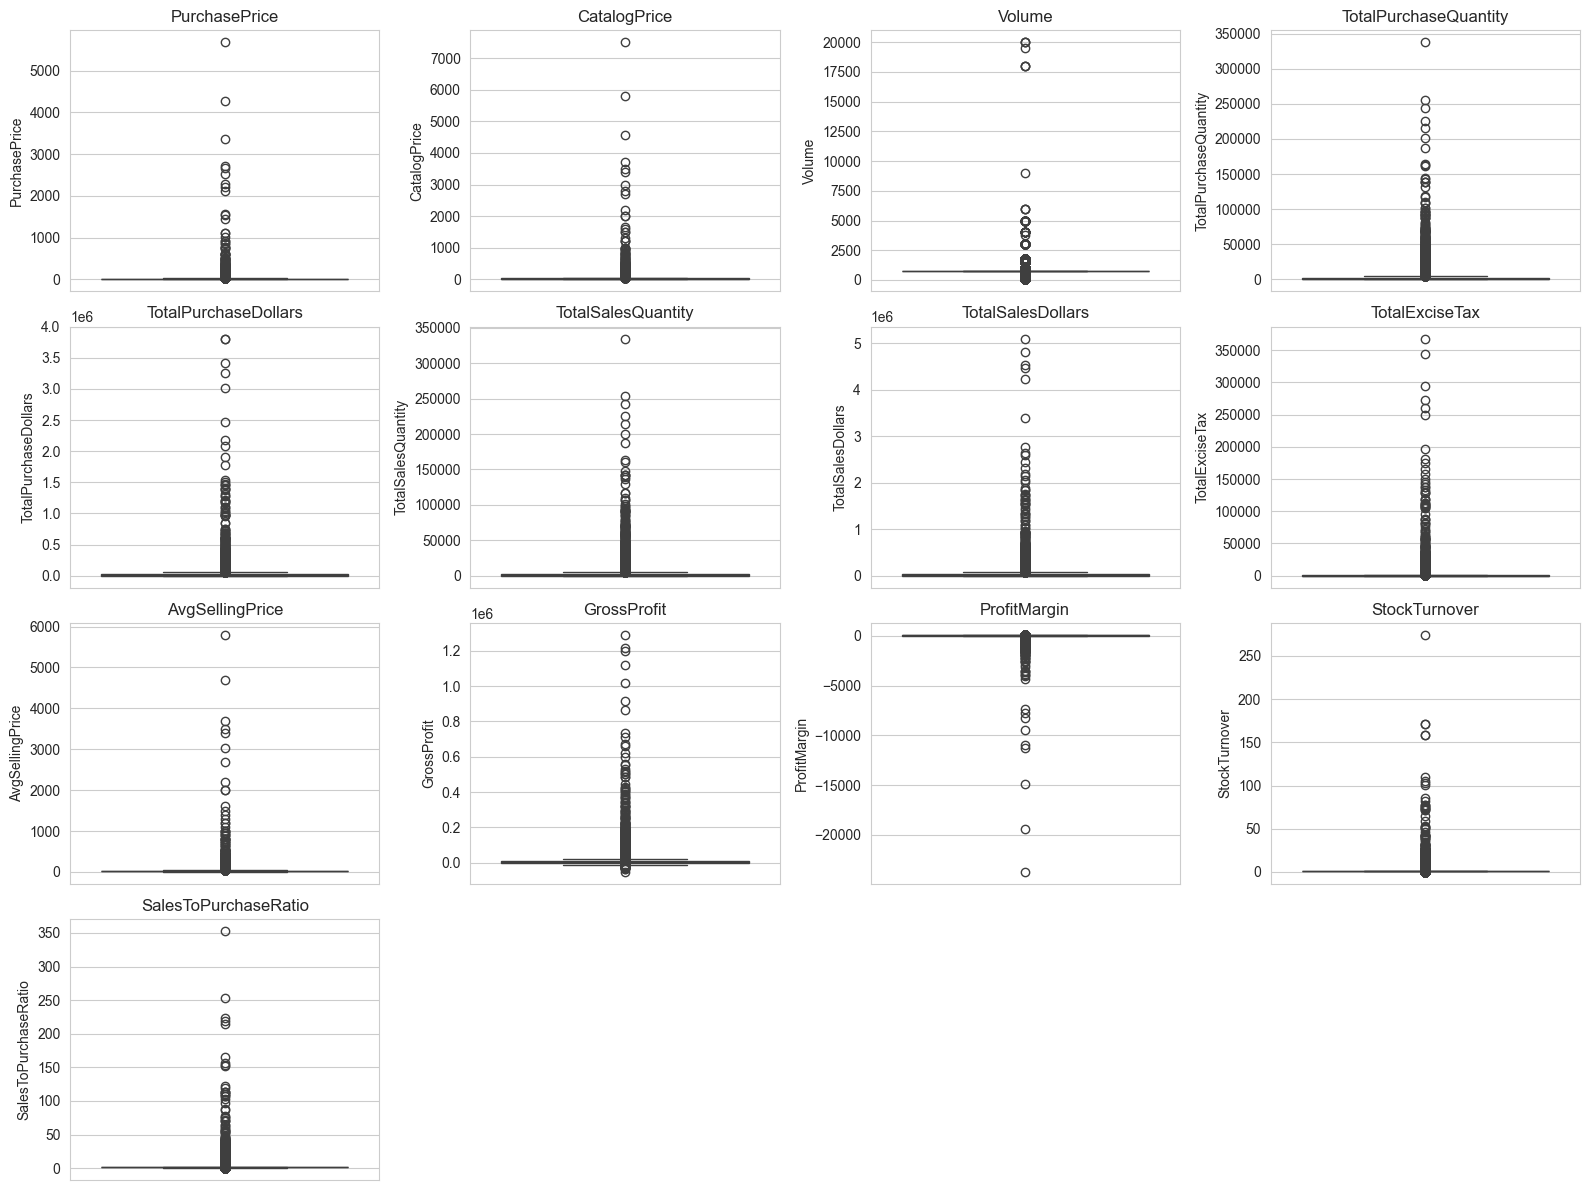

In [6]:
# Outlier detection with boxplots
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

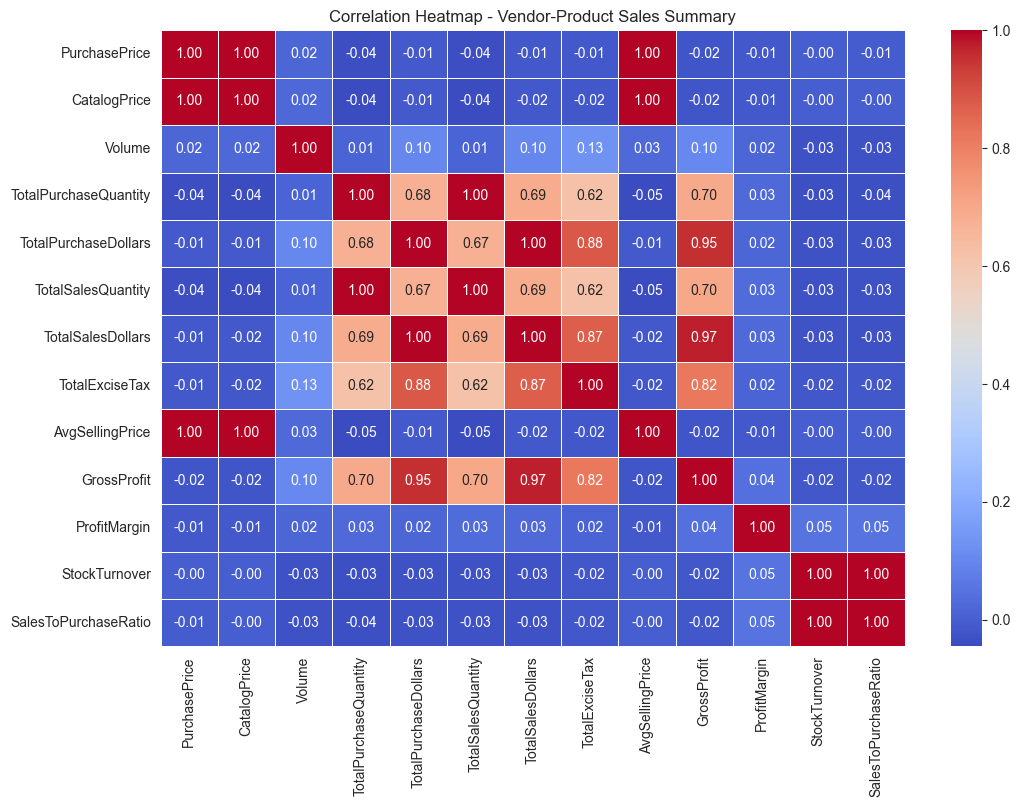

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Vendor-Product Sales Summary")
plt.show()

## 1.1 Company-wide totals

In [8]:
total_purchase = df['TotalPurchaseDollars'].sum()
total_sales = df['TotalSalesDollars'].sum()
total_profit = df['GrossProfit'].sum()
overall_margin = total_profit / total_sales * 100
dead_capital = df.loc[df['IsDeadStock']==1, 'TotalPurchaseDollars'].sum()

print(f"Total Purchases       : {format_dollars(total_purchase)}")
print(f"Total Sales           : {format_dollars(total_sales)}")
print(f"Total Gross Profit    : {format_dollars(total_profit)}")
print(f"Overall Profit Margin : {overall_margin:.2f}%")
print(f"Capital tied up in unsold (dead) stock: {format_dollars(dead_capital)}")

Total Purchases       : $321.90M
Total Sales           : $451.72M
Total Gross Profit    : $129.82M
Overall Profit Margin : 28.74%
Capital tied up in unsold (dead) stock: $282.18K


## 1.2 Vendor concentration

How much of total sales and purchases comes from just a handful of vendors?

In [9]:
vendor_performance = df.groupby('VendorName').agg(
    TotalPurchaseDollars=('TotalPurchaseDollars', 'sum'),
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

vendor_performance['Purchase_Contribution%'] = (
    vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum() * 100
)
vendor_performance = vendor_performance.sort_values('Purchase_Contribution%', ascending=False)

top_vendors = vendor_performance.head(10).copy()
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()
top_vendors.round(2)

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,Purchase_Contribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,50959796.85,68739834.97,17780038.12,15.83,15.83
63,MARTIGNETTI COMPANIES,27861690.02,40961033.22,13099343.20,8.66,24.49
50,JIM BEAM BRANDS COMPANY,24203151.05,31898959.50,7695808.45,7.52,32.01
74,PERNOD RICARD USA,24124091.56,32279767.10,8155675.54,7.49,39.50
8,BACARDI USA INC,17624378.72,25005390.78,7381012.06,5.48,44.97
23,CONSTELLATION BRANDS INC,15573917.90,24467134.23,8893216.33,4.84,49.81
14,BROWN-FORMAN CORP,13529433.08,18476611.60,4947178.52,4.20,54.02
113,ULTRA BEVERAGE COMPANY LLP,13210613.93,17802646.10,4592032.17,4.10,58.12
33,E & J GALLO WINERY,12289608.09,18553918.57,6264310.48,3.82,61.94
59,M S WALKER INC,10935817.30,15436253.15,4500435.85,3.40,65.33


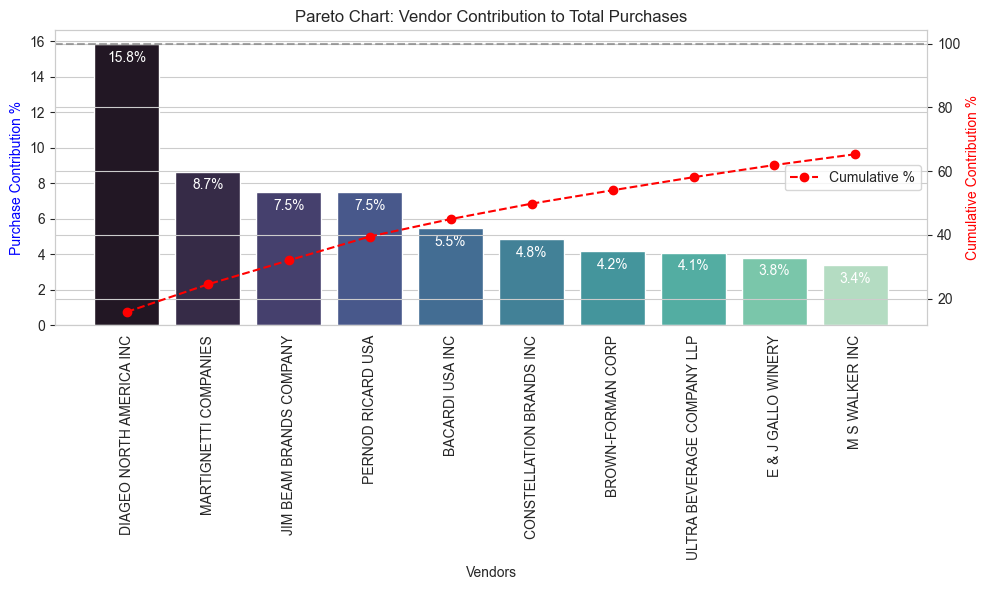

Top 10 vendors account for 65.3% of total purchases


In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'], palette="mako", ax=ax1)
for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, f"{value:.1f}%", ha='center', fontsize=10, color='white')

ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='center right')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')
plt.tight_layout()
plt.show()

print(f"Top 10 vendors account for {top_vendors['Purchase_Contribution%'].sum():.1f}% of total purchases")

In [11]:
# Concentration of sales and profit (the chart above ranks vendors by PURCHASE dollars).
# Here the top 10 are ranked by each measure separately.
total_sales_all = vendor_performance['TotalSalesDollars'].sum()
total_profit_all = vendor_performance['GrossProfit'].sum()

top10_sales = vendor_performance.nlargest(10, 'TotalSalesDollars')
top10_profit = vendor_performance.nlargest(10, 'GrossProfit')
top10_purchase_names = top_vendors['VendorName']
purchase_top10 = vendor_performance[vendor_performance['VendorName'].isin(top10_purchase_names)]

print(f"Top 10 vendors by sales account for {top10_sales['TotalSalesDollars'].sum() / total_sales_all * 100:.1f}% of total sales")
print(f"Top 10 vendors by gross profit account for {top10_profit['GrossProfit'].sum() / total_profit_all * 100:.1f}% of total gross profit")
print(f"The top 10 vendors by purchases (chart above) generate {purchase_top10['TotalSalesDollars'].sum() / total_sales_all * 100:.1f}% of sales "
      f"and {purchase_top10['GrossProfit'].sum() / total_profit_all * 100:.1f}% of gross profit")

Top 10 vendors by sales account for 65.0% of total sales
Top 10 vendors by gross profit account for 64.2% of total gross profit
The top 10 vendors by purchases (chart above) generate 65.0% of sales and 64.2% of gross profit


## 1.3 Which vendors carry the broadest product catalog?

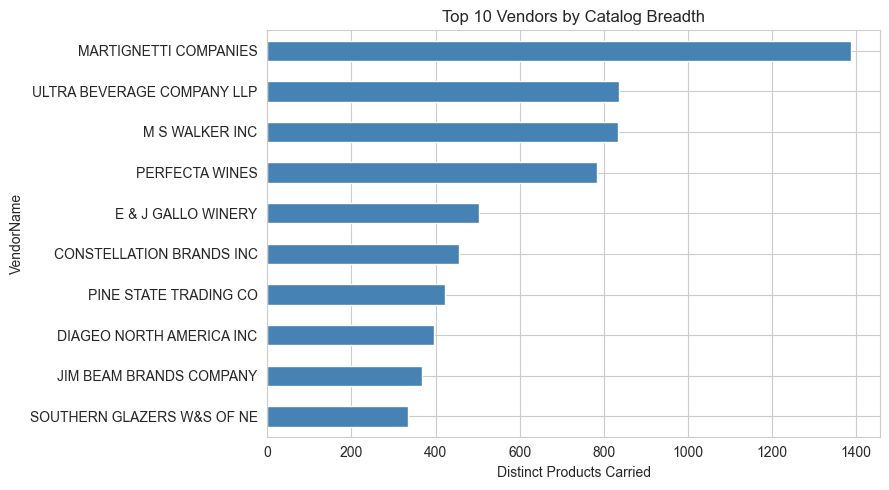

In [12]:
# how many distinct products a vendor supplies, regardless of how well those products sell.
catalog_breadth = df.groupby("VendorName")["ProductID"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
catalog_breadth.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Distinct Products Carried")
plt.title("Top 10 Vendors by Catalog Breadth")
plt.tight_layout()
plt.show()

## 1.4 Which vendors and products sell the most?

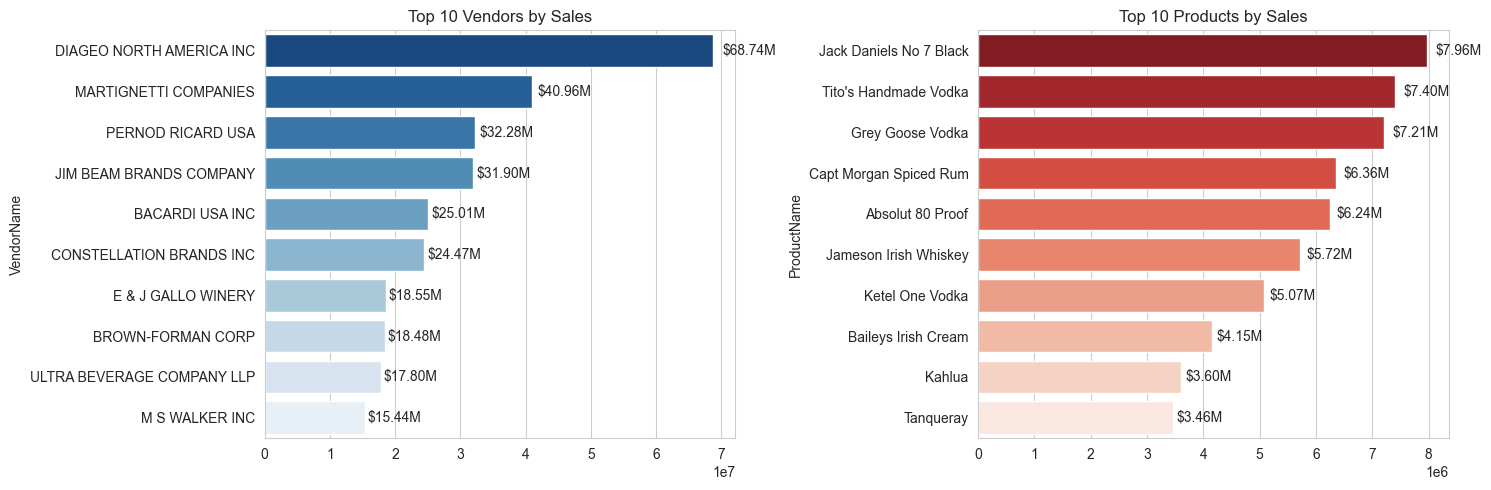

In [13]:
top_vendors_sales = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_products_sales = df.groupby("ProductName")["TotalSalesDollars"].sum().nlargest(10)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors_sales.index, x=top_vendors_sales.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")
for bar in ax1.patches:
    ax1.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()), ha='left', va='center', fontsize=10)

plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_products_sales.index.astype(str), x=top_products_sales.values, palette="Reds_r")
plt.title("Top 10 Products by Sales")
for bar in ax2.patches:
    ax2.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()), ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 1.5 Which products need promotional or pricing adjustments?

Looking for products with low total sales but a high profit margin, good candidates for a promotional push, since the margin is already there.

In [14]:
product_performance = df.groupby('ProductName').agg(
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    ProfitMargin=('ProfitMargin', 'mean')
).reset_index()

low_sales_threshold = product_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = product_performance['ProfitMargin'].quantile(0.85)

target_products = product_performance[
    (product_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (product_performance['ProfitMargin'] >= high_margin_threshold)
]

print(f"Low sales threshold  : {format_dollars(low_sales_threshold)}")
print(f"High margin threshold: {high_margin_threshold:.1f}%")
print(f"Products flagged     : {len(target_products)}")
display(target_products.sort_values('TotalSalesDollars').head(10))

Low sales threshold  : $286.31
High margin threshold: 56.7%
Products flagged     : 105


,ProductName,TotalSalesDollars,ProfitMargin
7777,Santa Rita Organic Svgn Bl,9.99,66.47
2896,Debauchery Pnt Nr,11.58,65.98
2537,Concannon Glen Ellen Wh Zin,15.95,83.45
2677,Crown Royal Apple,27.86,89.81
7818,Sauza Sprklg Wild Berry Marg,27.96,82.15
6050,Merry Irish Cream Liqueur,35.97,73.53
2223,Chambord Vodka,35.98,63.51
8984,Tracia Syrah,44.94,88.50
743,Basilica Amaretto,47.45,85.08
2649,Creme Yvette Liqueur,47.98,61.84


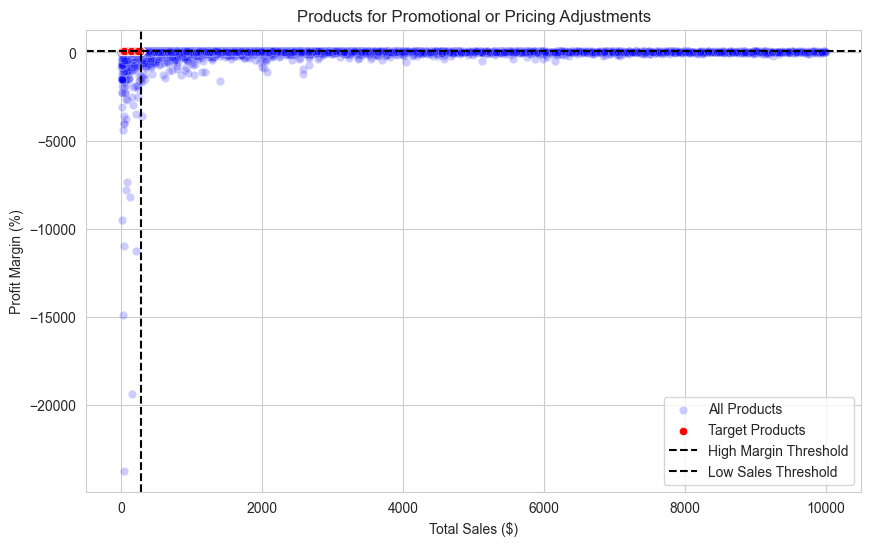

In [15]:
plot_data = product_performance[product_performance['TotalSalesDollars'] < 10_000]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Products", alpha=0.2)
sns.scatterplot(data=target_products, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Products")
plt.axhline(high_margin_threshold, ls='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, ls='--', color='black', label="Low Sales Threshold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Products for Promotional or Pricing Adjustments")
plt.legend()
plt.show()

## 1.6 Which vendors are actually the most/least profitable?

In [16]:
# We calculate vendor margin using total gross profit divided by total sales. This gives the overall margin for each vendor 
# based on their combined sales.
MIN_SALES_THRESHOLD = 10_000
vendor_margin = vendor_performance[vendor_performance['TotalSalesDollars'] >= MIN_SALES_THRESHOLD].copy()
vendor_margin['Margin'] = vendor_margin['GrossProfit'] / vendor_margin['TotalSalesDollars'] * 100

print(f"Vendors with sales >= {format_dollars(MIN_SALES_THRESHOLD)}: {len(vendor_margin)} of {len(vendor_performance)}")
print("\nTop 10 by profit margin:")
display(vendor_margin.sort_values('Margin', ascending=False).head(10)[['VendorName','TotalSalesDollars','Margin']])
print("\nBottom 10 by profit margin:")
display(vendor_margin.sort_values('Margin').head(10)[['VendorName','TotalSalesDollars','Margin']])

Vendors with sales >= $10.00K: 105 of 126

Top 10 by profit margin:


,VendorName,TotalSalesDollars,Margin
2,ALISA CARR BEVERAGES,113590.18,69.230016
108,THE PIERPONT GROUP LLC,17531.50,67.411859
82,R.P.IMPORTS INC,50845.60,63.070807
115,VINEDREA WINES LLC,11385.60,59.092187
11,BLACK PRINCE DISTILLERY INC,11697.04,48.944861
119,VRANKEN AMERICA,341398.51,38.977428
77,POVERTY LANE ORCHARDS,73642.09,38.528347
9,BANFI PRODUCTS CORP,2645625.22,38.431692
27,DIAGEO CHATEAU ESTATE WINES,2182527.26,37.436162
109,TREASURY WINE ESTATES,4740065.47,37.159383



Bottom 10 by profit margin:


,VendorName,TotalSalesDollars,Margin
1,ADAMBA IMPORTS INTL INC,67576.22,-13.605422
106,TAMWORTH DISTILLING,40021.12,-2.536960
95,STARK BREWING COMPANY,25371.54,-2.323470
84,Russian Standard Vodka,139135.55,0.164070
102,SWEETWATER FARM,35049.63,0.974618
15,BULLY BOY DISTILLERS,119484.53,1.302520
105,TALL SHIP DISTILLERY LLC,49533.14,2.195621
69,NICHE W & S,114938.96,3.399361
25,Circa Wines,44414.87,4.188980
54,LAIRD & CO,213108.09,4.737741


## 1.7 Margin vs. turnover: the two axes that matter for vendor strategy

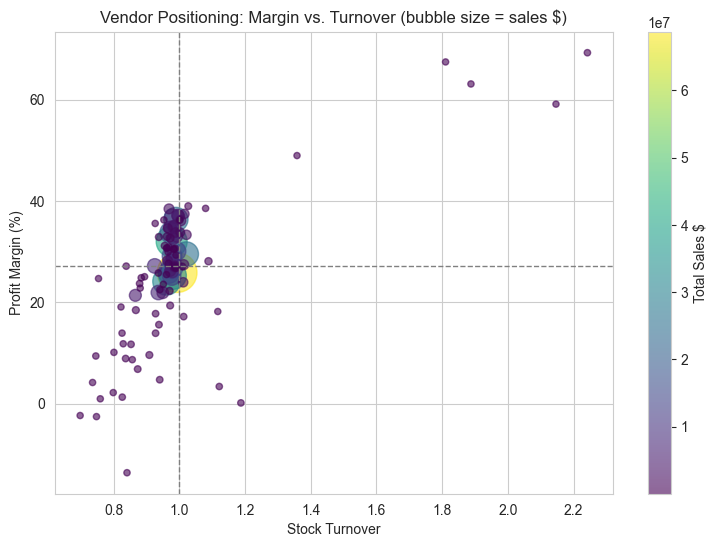

In [17]:
vendor_flow = df.groupby('VendorName', as_index=False).agg(
    TotalPurchaseQuantity=('TotalPurchaseQuantity', 'sum'),
    TotalSalesQuantity=('TotalSalesQuantity', 'sum')
)
vendor_flow['StockTurnover'] = vendor_flow['TotalSalesQuantity'] / vendor_flow['TotalPurchaseQuantity']

plot_df = vendor_margin.merge(vendor_flow[['VendorName', 'StockTurnover']], on='VendorName')

plt.figure(figsize=(9, 6))
sc = plt.scatter(plot_df['StockTurnover'], plot_df['Margin'],
                  s=plot_df['TotalSalesDollars'] / plot_df['TotalSalesDollars'].max() * 800 + 20,
                  alpha=0.6, c=plot_df['TotalSalesDollars'], cmap='viridis')
plt.axhline(plot_df['Margin'].median(), ls='--', color='gray', lw=1)
plt.axvline(1.0, ls='--', color='gray', lw=1)
plt.xlabel('Stock Turnover')
plt.ylabel('Profit Margin (%)')
plt.title('Vendor Positioning: Margin vs. Turnover (bubble size = sales $)')
plt.colorbar(sc, label='Total Sales $')
plt.show()

In [18]:
print("Correlation between vendor margin and stock turnover:",
      plot_df['Margin'].corr(plot_df['StockTurnover']).round(2))

Correlation between vendor margin and stock turnover: 0.71


**Reading this chart:** most large vendors (the big bubbles) cluster tightly around a turnover of 1.0 with margins
roughly between 20% and 40%, so for the vendors that matter most by sales, turnover and margin barely differ. The
differences show up among smaller vendors: the highest-margin vendors are small and turn stock faster than they buy it
(turnover well above 1), while the weakest margins belong to small vendors that sell less than they buy (turnover below
1). Among these smaller vendors, margin and turnover therefore tend to move together rather than trade off. The
correlation printed above summarises this.

## 1.8 Which vendors have slow-moving stock?

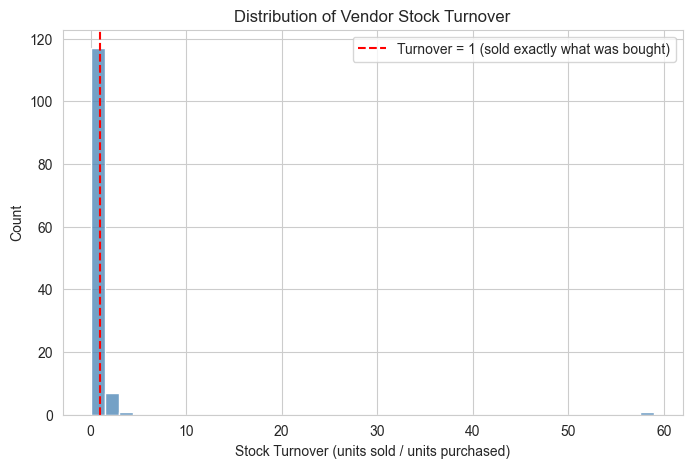

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(vendor_flow['StockTurnover'], bins=40, color='steelblue')
plt.axvline(1.0, ls='--', color='red', label='Turnover = 1 (sold exactly what was bought)')
plt.xlabel('Stock Turnover (units sold / units purchased)')
plt.title('Distribution of Vendor Stock Turnover')
plt.legend()
plt.show()

In [20]:
# Vendor-level turnover = total units sold / total units purchased (volume-weighted), so a vendor
# is not judged on the simple average of its individual product ratios.
# Vendors with fewer than 100 units purchased are excluded as too small to judge.
MIN_UNITS_PURCHASED = 100
slow_vendors = vendor_flow[(vendor_flow['StockTurnover'] < 1) &
                           (vendor_flow['TotalPurchaseQuantity'] >= MIN_UNITS_PURCHASED)]
slow_vendors.sort_values('StockTurnover').head(10).set_index('VendorName')[
    ['StockTurnover', 'TotalPurchaseQuantity', 'TotalSalesQuantity']]

,StockTurnover,TotalPurchaseQuantity,TotalSalesQuantity
VendorName,,,
"IRA GOLDMAN AND WILLIAMS, LLP",0.128049,328,42
HIGHLAND WINE MERCHANTS LLC,0.220430,372,82
UNCORKED,0.251029,243,61
LOYAL DOG WINERY,0.308333,240,74
BLACK COVE BEVERAGES,0.340588,919,313
GILMANTON WINERY & VINEYARD,0.465116,516,240
APPOLO VINEYARDS LLC,0.469565,230,108
STARK BREWING COMPANY,0.698020,1212,846
Circa Wines,0.735843,3320,2443


## 1.9 Does purchasing in bulk reduce the unit price?

In [21]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.305634


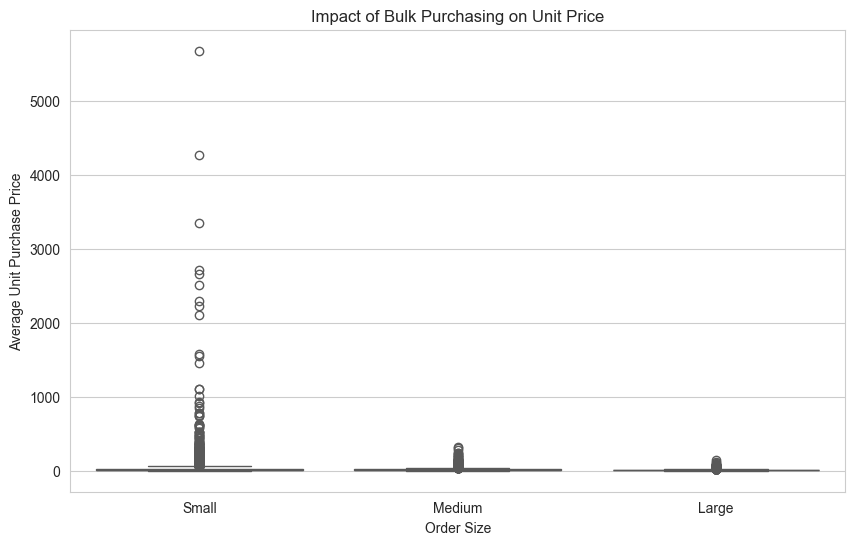

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

**Caution when reading this:** `OrderSize` groups products by their total purchased quantity for the year, and each
product appears once. Cheap products naturally sell in high volumes and expensive ones in low volumes, so the falling
unit price from Small to Large mostly reflects a product-mix effect. It is not evidence that buying more of the same
product earns a volume discount. Testing that would need repeated purchases of the same product at different order
sizes.

## 1.10 How much capital is locked in unsold inventory?

In [23]:
# Only surplus stock counts: products that sold MORE than was purchased (sold out of opening
# inventory) are set to 0 so they do not cancel out overstock on other products.
df['UnsoldInventoryValue'] = ((df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']).clip(lower=0)
                              * df['PurchasePrice'])
print("Total Unsold Capital:", format_dollars(df['UnsoldInventoryValue'].sum()))

inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().sort_values(ascending=False)
inventory_value_per_vendor.head(10).apply(format_dollars)

Total Unsold Capital: $15.60M


VendorName
MARTIGNETTI COMPANIES           $1.93M
DIAGEO NORTH AMERICA INC        $1.66M
ULTRA BEVERAGE COMPANY LLP      $1.48M
JIM BEAM BRANDS COMPANY         $1.14M
PERFECTA WINES                $915.54K
M S WALKER INC                $849.94K
PERNOD RICARD USA             $723.10K
WILLIAM GRANT & SONS INC      $502.62K
E & J GALLO WINERY            $486.80K
CONSTELLATION BRANDS INC      $448.59K
Name: UnsoldInventoryValue, dtype: object

**Note:** this is a broader metric than the dead-stock capital in Section 6.
`UnsoldInventoryValue` counts any leftover surplus: a product that sold 80 of 100 units
still counts 20 units here, and a product that sold more than it purchased counts as zero.
Section 6 only counts products that sold **zero** units all year. Both are valid and
complementary: this measures general overstocking, Section 6 measures complete non-movers specifically.

## 1.11 Does bottle size format affect profitability?

In [24]:
# Margin by bottle size, calculated the sales-weighted way: total gross profit / total sales dollars.
format_performance = df.groupby('BottleSizeCategory').agg(
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    GrossProfit=('GrossProfit', 'sum'),
    ProductCount=('ProductID', 'count'),
    MedianRowMargin=('ProfitMargin', 'median')
).sort_values('TotalSalesDollars', ascending=False)
format_performance['SalesShare%'] = format_performance['TotalSalesDollars'] / format_performance['TotalSalesDollars'].sum() * 100
format_performance['WeightedMargin'] = format_performance['GrossProfit'] / format_performance['TotalSalesDollars'] * 100
format_performance

,TotalSalesDollars,GrossProfit,ProductCount,MedianRowMargin,SalesShare%,WeightedMargin
BottleSizeCategory,,,,,,
Standard,2.668598e+08,79081173.79,8961,31.03,59.076072,29.633976
Large,1.520347e+08,41573570.70,845,30.38,33.656672,27.344789
Half Bottle,1.478900e+07,3744290.91,456,27.38,3.273914,25.318075
Mini,9.659161e+06,2331624.15,262,24.17,2.138296,24.138993
Bulk,8.372736e+06,3085176.64,166,33.76,1.853514,36.847893
Unknown,6.917990e+03,5745.08,3,86.39,0.001531,83.045509


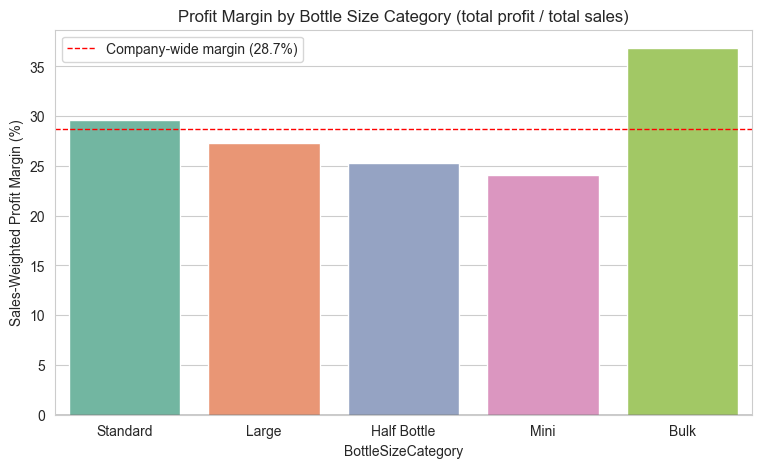

Check: margin across all formats = 28.74% (company-wide margin from Section 1.1 = 28.74%)
Among formats with at least 1% of sales: highest margin = Bulk (36.8%), lowest margin = Mini (24.1%)


In [25]:
# The 'Unknown' category (3 products, under 0.01% of sales) is left out of the chart so its
# unrepresentative margin does not stretch the axis. It is still shown in the table above.
plot_fp = format_performance[format_performance['SalesShare%'] >= 0.1]

plt.figure(figsize=(9, 5))
sns.barplot(x=plot_fp.index, y=plot_fp['WeightedMargin'], palette="Set2")
plt.axhline(0, color='black', lw=1)
plt.axhline(overall_margin, color='red', ls='--', lw=1, label=f'Company-wide margin ({overall_margin:.1f}%)')
plt.ylabel("Sales-Weighted Profit Margin (%)")
plt.title("Profit Margin by Bottle Size Category (total profit / total sales)")
plt.legend()
plt.show()

# Sanity check + data-driven summary of the chart
check_margin = format_performance['GrossProfit'].sum() / format_performance['TotalSalesDollars'].sum() * 100
print(f"Check: margin across all formats = {check_margin:.2f}% (company-wide margin from Section 1.1 = {overall_margin:.2f}%)")
material = format_performance[format_performance['SalesShare%'] >= 1]
best_fmt, worst_fmt = material['WeightedMargin'].idxmax(), material['WeightedMargin'].idxmin()
print(f"Among formats with at least 1% of sales: highest margin = {best_fmt} ({material.loc[best_fmt, 'WeightedMargin']:.1f}%), "
      f"lowest margin = {worst_fmt} ({material.loc[worst_fmt, 'WeightedMargin']:.1f}%)")

**Finding:** measured on a sales-weighted basis, margins by bottle size are close together, and they reconcile with the
company-wide 28.7% (see the check printed above). The two formats that carry about 93% of sales, Standard (29.6%) and
Large (27.3%), sit within about 1.5 points of the company margin. Bulk has the highest margin (36.8%) but only 1.9% of
sales, while Half Bottle (25.3%) and Mini (24.1%) have the lowest margins, on a combined 5.4% of sales. Every format earns
a healthy positive margin, so bottle size is not a major profitability driver here. The `Unknown` category (3 products,
under 0.01% of sales) is left out of the chart and should not be interpreted.

## 1.12 Does product Classification affect profitability?

In [26]:
# Sales-weighted margin by classification (total gross profit / total sales dollars)

class_performance = df.groupby('Classification').agg(
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    GrossProfit=('GrossProfit', 'sum'),
    ProductCount=('ProductID', 'count'),
    MedianRowMargin=('ProfitMargin', 'median')
).sort_values('TotalSalesDollars', ascending=False)
class_performance['SalesShare%'] = class_performance['TotalSalesDollars'] / class_performance['TotalSalesDollars'].sum() * 100
class_performance['WeightedMargin'] = class_performance['GrossProfit'] / class_performance['TotalSalesDollars'] * 100
display(class_performance)

check_margin = class_performance['GrossProfit'].sum() / class_performance['TotalSalesDollars'].sum() * 100
print(f"Check: margin across both classifications = {check_margin:.2f}% (company-wide margin from Section 1.1 = {overall_margin:.2f}%)")

,TotalSalesDollars,GrossProfit,ProductCount,MedianRowMargin,SalesShare%,WeightedMargin
Classification,,,,,,
1,2.900970e+08,73132205.02,3167,26.05,64.22021,25.209566
2,1.616253e+08,56689376.25,7526,32.53,35.77979,35.074566


Check: margin across both classifications = 28.74% (company-wide margin from Section 1.1 = 28.74%)


**Finding:** classification margins are sales-weighted (total gross profit / total sales dollars) and reconcile with the
company-wide margin, as the check above shows. Classification 2 earns a clearly higher margin than Classification 1 on
both measures: 35.1% versus 25.2% weighted, and a median row margin of 32.5% versus 26.1%. Classification 1 carries 64.2%
of sales and Classification 2 the remaining 35.8%, so the higher-margin group is the smaller one. `Classification` isn't
documented in the source data, so what it represents should be confirmed before drawing business conclusions from this
difference.

## 1.13 Does freight cost relate to profit margin?

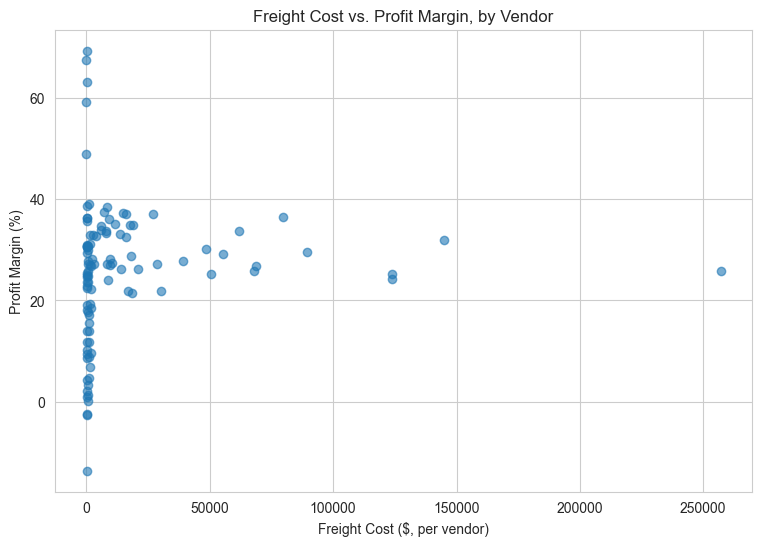

Correlation: 0.085


In [27]:
# FreightCost repeats across every product row for the same vendor (it's a vendor-level
# total, not per-product) - drop_duplicates by vendor first so each vendor counts once
vendor_freight = df.drop_duplicates('VendorName')[['VendorName', 'FreightCost']]
freight_margin = vendor_margin.merge(vendor_freight, on='VendorName')

plt.figure(figsize=(9, 6))
plt.scatter(freight_margin['FreightCost'], freight_margin['Margin'], alpha=0.6)
plt.xlabel("Freight Cost ($, per vendor)")
plt.ylabel("Profit Margin (%)")
plt.title("Freight Cost vs. Profit Margin, by Vendor")
plt.show()

print("Correlation:", freight_margin['FreightCost'].corr(freight_margin['Margin']).round(3))

**Finding:** essentially no relationship (correlation ~ 0.085).
Freight cost has almost no relationship with vendor profitability in this data.

## 1.14 The free-sample product, in detail

In [28]:
df[df['IsFreeSample'] == 1][
    ['VendorName', 'ProductName', 'PurchasePrice', 'TotalPurchaseQuantity', 'TotalSalesQuantity', 'TotalSalesDollars']
]

,VendorName,ProductName,PurchasePrice,TotalPurchaseQuantity,TotalSalesQuantity,TotalSalesDollars
1968,EDRINGTON AMERICAS,The Macallan Double Cask 12,0.0,2015,1732,98245.68


This is the product received at $0
(`PurchasePrice = 0`) but sold for real revenue. Shown directly here rather than just
described, since it's a concrete, checkable finding.

## 1.15 Do top-selling and low-selling vendor products have different profit margins?

Top-selling rows (n=2,674):  median row margin = 30.69%  |  sales-weighted margin = 29.25%
Low-selling rows (n=2,497):  median row margin = 20.47%  |  sales-weighted margin = -87.52%


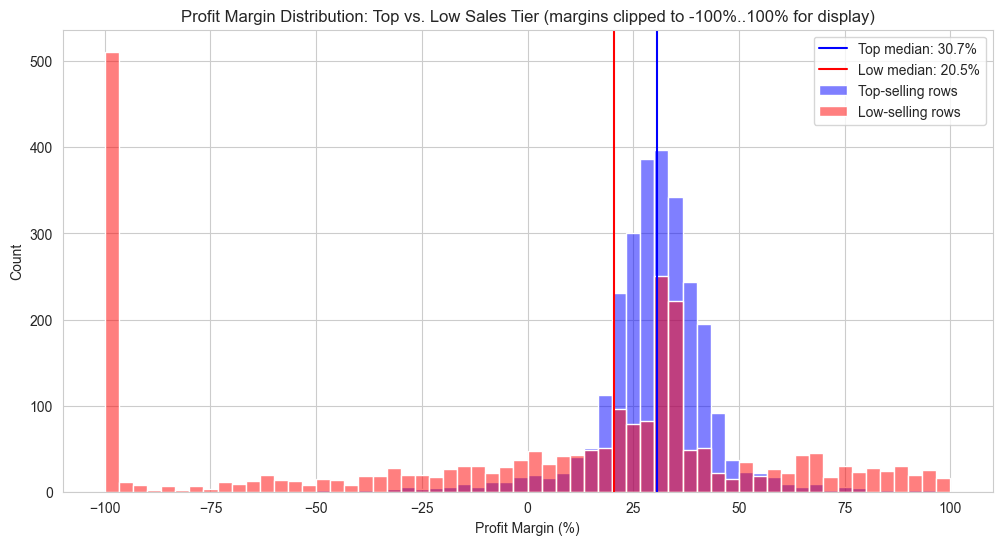

In [29]:
# Compare the top 25% vs bottom 25% of vendor-product rows by sales dollars.
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_rows = df[df['TotalSalesDollars'] >= top_threshold]
low_rows = df[df['TotalSalesDollars'] <= low_threshold]

top_vendor_margins = top_rows['ProfitMargin'].dropna()
low_vendor_margins = low_rows['ProfitMargin'].dropna()

# Row-level margins are extremely skewed, so medians and the sales-weighted (dollar) margin are
# used instead of a mean and confidence interval, which a few extreme rows would dominate.
top_weighted = top_rows['GrossProfit'].sum() / top_rows['TotalSalesDollars'].sum() * 100
low_weighted = low_rows['GrossProfit'].sum() / low_rows['TotalSalesDollars'].sum() * 100

print(f"Top-selling rows (n={len(top_vendor_margins):,}):  median row margin = {top_vendor_margins.median():.2f}%  |  sales-weighted margin = {top_weighted:.2f}%")
print(f"Low-selling rows (n={len(low_vendor_margins):,}):  median row margin = {low_vendor_margins.median():.2f}%  |  sales-weighted margin = {low_weighted:.2f}%")

plt.figure(figsize=(12, 6))
bins = np.linspace(-100, 100, 61)
sns.histplot(top_vendor_margins.clip(-100, 100), bins=bins, color="blue", alpha=0.5, label="Top-selling rows")
plt.axvline(top_vendor_margins.median(), color="blue", label=f"Top median: {top_vendor_margins.median():.1f}%")
sns.histplot(low_vendor_margins.clip(-100, 100), bins=bins, color="red", alpha=0.5, label="Low-selling rows")
plt.axvline(low_vendor_margins.median(), color="red", label=f"Low median: {low_vendor_margins.median():.1f}%")
plt.title("Profit Margin Distribution: Top vs. Low Sales Tier (margins clipped to -100%..100% for display)")
plt.xlabel("Profit Margin (%)")
plt.legend()
plt.show()

**Two notes on this result:**
- **Grain:** this table is one row per (vendor, product), so "top/low" here means
  "top/low vendor-product line items," not one data point per vendor.
- **Why medians and weighted margins:** low-selling rows include products with very low sales and large losses, which
  produce extreme negative row margins (below -100%, so the histogram is clipped for display).

**Result:** the top-selling tier earns a sales-weighted margin of about 29.3% (median row margin 30.7%). The low-selling
tier loses money in aggregate, with a sales-weighted margin of about -87.5%, even though its typical row still earns a
positive margin (median 20.5%). That gap means a minority of low-selling rows, where purchases are far above sales,
outweigh the profitable ones in dollar terms.

### Is the margin difference statistically significant?

Mann-Whitney U test compares the two groups without assuming a normal distribution.

- H0 (Null): the top-selling and low-selling rows have the same profit-margin distribution.
- H1 (Alternative): the two distributions are different.

In [30]:
u_stat, p_value = mannwhitneyu(top_vendor_margins, low_vendor_margins, alternative='two-sided')
print(f"Mann-Whitney U: {u_stat:,.0f}, P-Value: {p_value:.4g}")
if p_value < 0.05:
    higher = 'top-selling' if top_vendor_margins.median() > low_vendor_margins.median() else 'low-selling'
    print(f"Reject H0: the margin distributions differ significantly; the {higher} tier has the higher median margin.")
else:
    print("Fail to reject H0: no significant difference in profit margin.")

Mann-Whitney U: 4,288,982, P-Value: 3.033e-70
Reject H0: the margin distributions differ significantly; the top-selling tier has the higher median margin.


## 1.16 Does the actual selling price match the catalog price?

`AvgSellingPrice` (the real, revenue-weighted price products actually sold at) Worth checking directly against
`CatalogPrice` (the static reference price).

In [31]:
priced = df.dropna(subset=['AvgSellingPrice']).copy()
priced['PriceDiff'] = priced['AvgSellingPrice'] - priced['CatalogPrice']

pct_diverged = (priced['PriceDiff'].abs() > 1).mean() * 100
print(f"Products where actual selling price differs from catalog price by more than $1: {pct_diverged:.1f}%")
print("Correlation between AvgSellingPrice and TotalSalesDollars:",
      priced['AvgSellingPrice'].corr(priced['TotalSalesDollars']).round(3))

Products where actual selling price differs from catalog price by more than $1: 26.6%
Correlation between AvgSellingPrice and TotalSalesDollars: -0.015


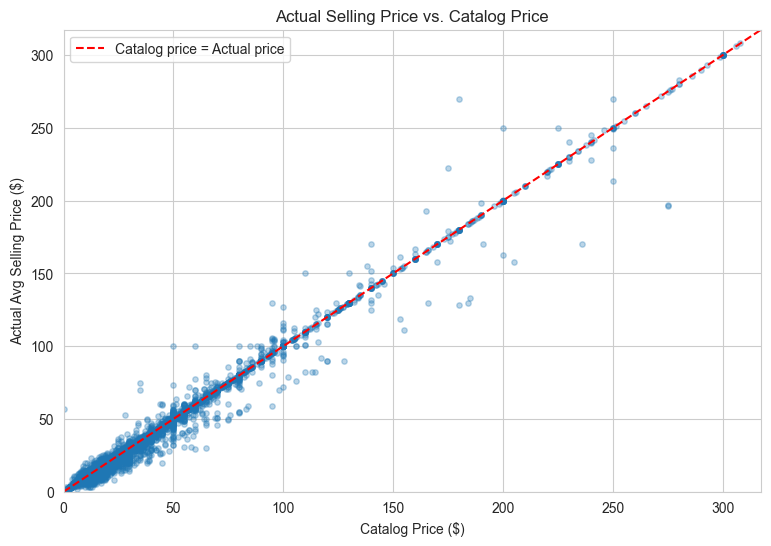

In [32]:
plt.figure(figsize=(9, 6))
plt.scatter(priced['CatalogPrice'], priced['AvgSellingPrice'], alpha=0.3, s=15)
max_price = min(priced['CatalogPrice'].quantile(0.99), priced['AvgSellingPrice'].quantile(0.99))
plt.plot([0, max_price], [0, max_price], color='red', ls='--', label='Catalog price = Actual price')
plt.xlim(0, max_price)
plt.ylim(0, max_price)
plt.xlabel("Catalog Price ($)")
plt.ylabel("Actual Avg Selling Price ($)")
plt.title("Actual Selling Price vs. Catalog Price")
plt.legend()
plt.show()

**Finding:** About 27% of products (26.6%, from the output above) have a difference of more than $1 between their
actual selling price and catalog price. Also, actual selling price has almost no relationship with total sales
(correlation -0.015), meaning higher-priced products do not necessarily generate higher revenue.

# 2. Procurement & Logistics Summary

Grain: one row per PONumber. Source: `procurement_logistics_summary`
(purchases + vendor_invoice). Covers freight efficiency, lead times, and payment
behavior.

In [33]:
proc = pd.read_sql_query("select * from procurement_logistics_summary", engine)
proc.head()

,VendorNumber,VendorName,PONumber,PODate,InvoiceDate,PayDate,PaymentLagDays,InvoiceQuantity,POTotalAmount,Freight,LandedCost,TotalPurchaseQuantity,TotalPurchaseDollars,MinReceivingDate,MaxReceivingDate,FreightPctOfPurchase,OrderToReceiveDays,ReceiveToInvoiceDays,InvoiceToPayDays,QuantityMismatch
0,480,BACARDI USA INC,8106,2023-12-20,2024-01-12,2024-02-05,24,10100,137483.78,2935.20,140418.98,10100,137483.78,2024-01-01,2024-01-03,2.1349,12.0,9.0,24,0
1,90046,CANDIA VINEYARDS,8107,2023-12-20,2024-01-05,2024-02-10,36,24,348.72,9.08,357.80,24,348.72,2024-01-01,2024-01-02,2.6038,12.0,3.0,36,0
2,1392,CONSTELLATION BRANDS INC,8108,2023-12-20,2024-01-11,2024-02-10,30,8466,60281.13,1549.81,61830.94,8466,60281.13,2024-01-01,2024-01-03,2.5710,12.0,8.0,30,0
3,1590,DIAGEO CHATEAU ESTATE WINES,8109,2023-12-20,2024-01-12,2024-02-11,30,2246,14298.09,408.72,14706.81,2246,14298.09,2024-01-01,2024-01-03,2.8586,12.0,9.0,30,0
4,3252,E & J GALLO WINERY,8110,2023-12-20,2024-01-09,2024-02-19,41,8086,56493.23,1300.92,57794.15,8086,56493.23,2024-01-01,2024-01-03,2.3028,12.0,6.0,41,0


In [34]:
print(f"Rows (POs): {len(proc):,}  |  Distinct vendors: {proc['VendorName'].nunique()}")
proc.describe().T

Rows (POs): 5,543  |  Distinct vendors: 126


,count,mean,std,min,25%,50%,75%,max
VendorNumber,5543.0,20662.752120,34582.158410,2.0000,3089.0000,7240.00,10754.000,2.013590e+05
PONumber,5543.0,10889.419087,1600.859969,8106.0000,9503.5000,10890.00,12275.500,1.366100e+04
PaymentLagDays,5543.0,35.468519,5.842178,23.0000,31.0000,35.00,40.000,4.800000e+01
InvoiceQuantity,5543.0,6058.880931,14453.338164,1.0000,83.0000,423.00,5100.500,1.416600e+05
POTotalAmount,5543.0,58073.383642,140234.031377,4.1400,967.8100,4765.45,44587.175,1.660436e+06
Freight,5543.0,295.954301,713.585093,0.0200,5.0200,24.73,229.660,8.468220e+03
LandedCost,5543.0,58369.337943,140937.066515,4.1600,972.4100,4790.71,44794.505,1.668904e+06
TotalPurchaseQuantity,5543.0,4424.996753,12326.169122,0.0000,4.0000,130.00,2565.500,1.317120e+05
TotalPurchaseDollars,5543.0,41781.370568,116834.625737,0.0000,48.3000,1539.79,26382.620,1.377225e+06
FreightPctOfPurchase,5543.0,0.550504,0.480129,0.4416,0.4703,0.50,0.530,1.152250e+01


## 2.1 How much of the purchase amount being spent on freight?

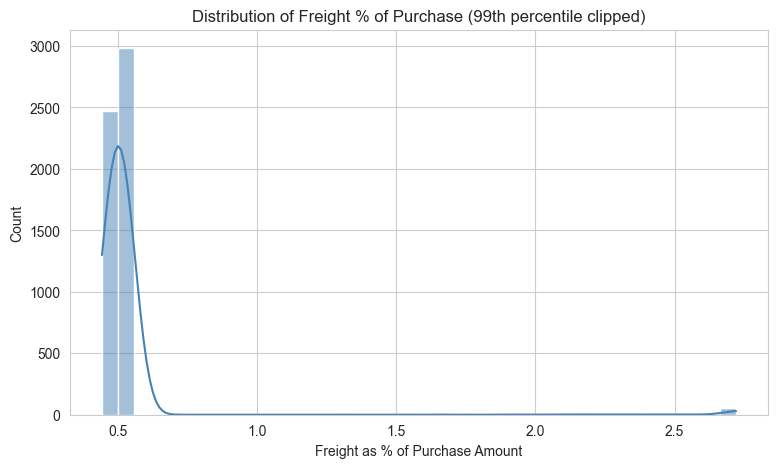

In [35]:
plt.figure(figsize=(9, 5))
sns.histplot(proc['FreightPctOfPurchase'].clip(upper=proc['FreightPctOfPurchase'].quantile(0.99)),
             kde=True, bins=40, color='steelblue')
plt.xlabel("Freight as % of Purchase Amount")
plt.title("Distribution of Freight % of Purchase (99th percentile clipped)")
plt.show()

In [36]:
freight_by_vendor = proc.groupby('VendorName').agg(
    AvgFreightPct=('FreightPctOfPurchase', 'mean'),
    POCount=('PONumber', 'count')
).query('POCount >= 5').sort_values('AvgFreightPct', ascending=False)

print("Highest average freight % (vendors with 5+ POs):")
freight_by_vendor.head(10)

Highest average freight % (vendors with 5+ POs):


,AvgFreightPct,POCount
VendorName,,
LAIRD & CO,0.704829,55
ZORVINO VINEYARDS,0.695600,55
CALEDONIA SPIRITS INC,0.684974,54
KLIN SPIRITS LLC,0.674783,54
PSP WINES,0.661269,54
TALL SHIP DISTILLERY LLC,0.656578,51
TAKARA SAKE USA INC,0.618807,55
PREMIER DISTRIBUTORS,0.617957,54
AMERICAN VINTAGE BEVERAGE,0.601884,55


**Finding:** freight is a small share of spend. The average PO pays about 0.55% of its value in freight (see the summary
statistics above), and even the vendors with the highest average freight percentage sit at roughly 0.6% to 0.7%.
Differences between vendors exist but are small in absolute terms, so freight negotiation is likely a low-impact lever
compared with margin or dead stock.

## 2.2 How do the procurement metrics relate to each other?

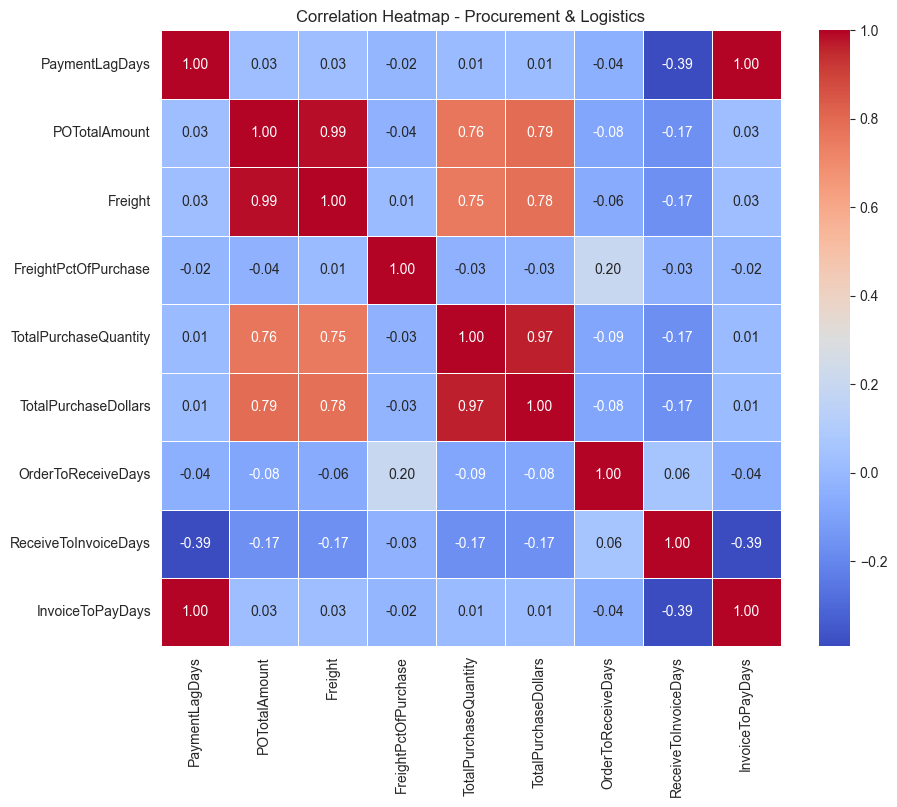

In [37]:
proc_numeric = ['PaymentLagDays', 'POTotalAmount', 'Freight', 'FreightPctOfPurchase',
                 'TotalPurchaseQuantity', 'TotalPurchaseDollars',
                 'OrderToReceiveDays', 'ReceiveToInvoiceDays', 'InvoiceToPayDays']

plt.figure(figsize=(10, 8))
sns.heatmap(proc[proc_numeric].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Procurement & Logistics")
plt.show()

## 2.3 Does freight amount scale with purchase order size?

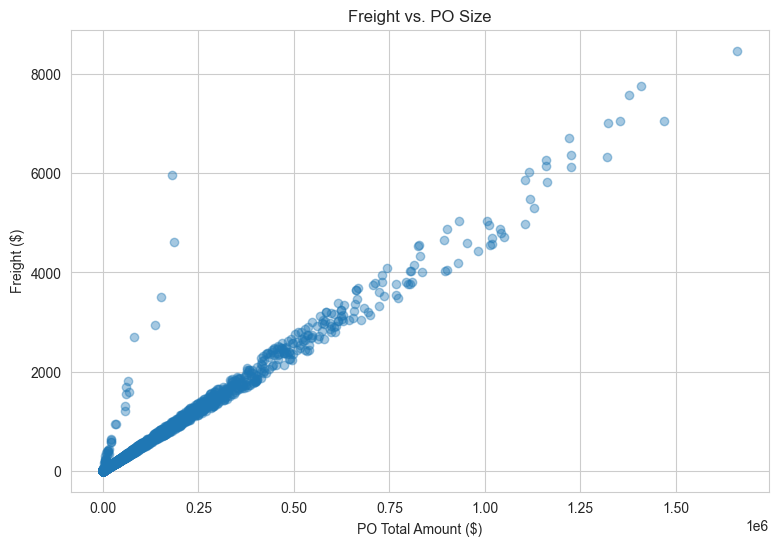

Correlation: 0.985


In [38]:
plt.figure(figsize=(9, 6))
plt.scatter(proc['POTotalAmount'], proc['Freight'], alpha=0.4)
plt.xlabel("PO Total Amount ($)")
plt.ylabel("Freight ($)")
plt.title("Freight vs. PO Size")
plt.show()

print("Correlation:", proc['POTotalAmount'].corr(proc['Freight']).round(3))

**Finding:** Freight cost increases strongly as purchase order size increases (correlation = 0.985). This is expected because larger orders cost more to ship. The more useful measure is freight as a percentage of purchase amount, which helps identify vendors who are charging unusually high freight rates regardless of order size.

## 2.4 Lead times: order to receive, receive to invoice, invoice to pay

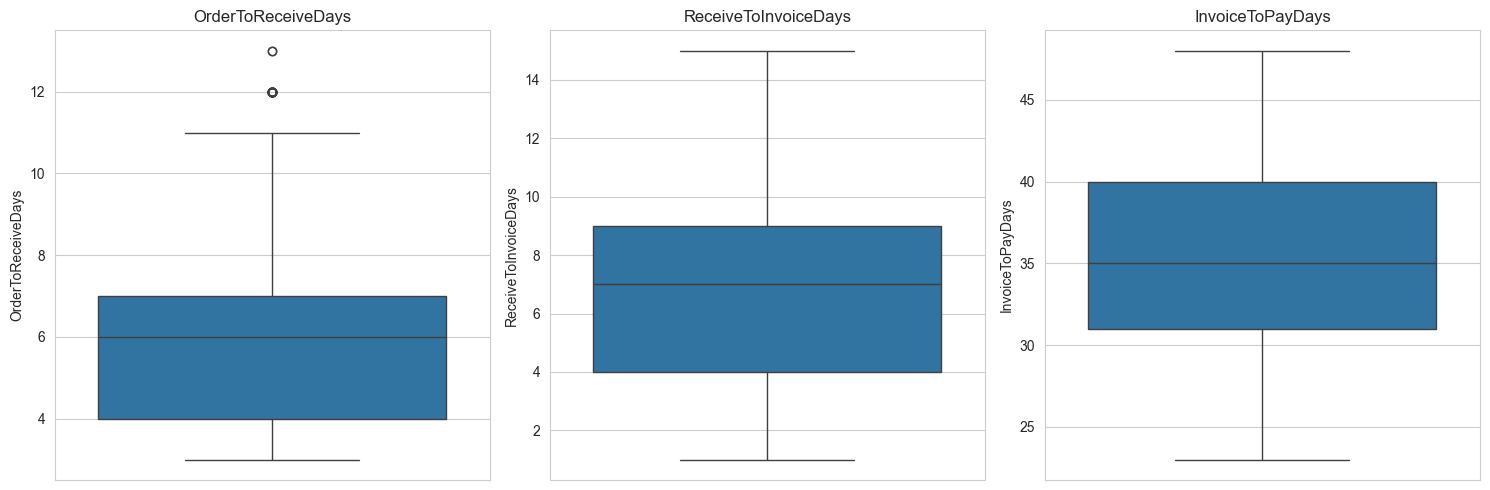

OrderToReceiveDays       6.0
ReceiveToInvoiceDays     7.0
InvoiceToPayDays        35.0
Name: Median Days, dtype: float64

In [39]:
lead_time_cols = ['OrderToReceiveDays', 'ReceiveToInvoiceDays', 'InvoiceToPayDays']

plt.figure(figsize=(15, 5))
for i, col in enumerate(lead_time_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=proc[col])
    plt.title(col)
plt.tight_layout()
plt.show()

proc[lead_time_cols].median().rename('Median Days')

**Coverage note:** the lead-time columns (`OrderToReceiveDays`, `ReceiveToInvoiceDays`) are only available for the 4,207
of 5,543 POs that have matching purchase (receiving) records. The 1,336 POs without them are examined in Section 2.7.
Lead-time statistics in Sections 2.4 and 2.5 therefore describe POs with receiving records only.

## 2.5 Which vendors are slow and inconsistent vs. slow but consistent?

In [40]:
# Average lead time alone doesn't tell if a vendor is reliably slow or just inconsistent-
# two vendors can share the same average with very different consistency.
lead_reliability = proc.groupby('VendorName').agg(
    AvgLeadDays=('OrderToReceiveDays', 'mean'),
    LeadDaysStdDev=('OrderToReceiveDays', 'std'),
    LeadTimePOs=('OrderToReceiveDays', 'count')
).query('LeadTimePOs >= 5').sort_values('LeadDaysStdDev', ascending=False)

print("Correlation between avg lead time and its variability:",
      lead_reliability['AvgLeadDays'].corr(lead_reliability['LeadDaysStdDev']).round(3))
print("\nLeast consistent vendors (highest lead-time variability, 5+ POs with receiving records):")
lead_reliability.head(10)

Correlation between avg lead time and its variability: 0.493

Least consistent vendors (highest lead-time variability, 5+ POs with receiving records):


,AvgLeadDays,LeadDaysStdDev,LeadTimePOs
VendorName,,,
ALISA CARR BEVERAGES,7.333333,2.890146,18
R.P.IMPORTS INC,7.214286,2.636389,14
ALTAMAR BRANDS LLC,7.620690,2.569238,29
APPOLO VINEYARDS LLC,7.300000,2.496664,10
Circa Wines,6.906250,2.493338,32
THE PIERPONT GROUP LLC,7.761905,2.447545,21
Russian Standard Vodka,6.289474,2.323882,38
CENTEUR IMPORTS LLC,7.551724,2.308156,29
"HOOD RIVER DISTILLERS, Inc.",6.933333,2.288402,30


**Finding:** the correlation is moderate (~0.49), not strong, meaning a vendor's average
speed and its consistency are genuinely different things. Some of the vendors above aren't
the slowest on average, but they're the least consistent, which matters just as much for
planning as the average itself.

## 2.6 Which vendors are slowest to pay?

In [41]:
pay_by_vendor = proc.groupby('VendorName').agg(
    AvgPayDays=('InvoiceToPayDays', 'mean'),
    POCount=('PONumber', 'count')
).query('POCount >= 5').sort_values('AvgPayDays', ascending=False)

print("Slowest average payment turnaround (5+ POs):")
pay_by_vendor.head(10)

Slowest average payment turnaround (5+ POs):


,AvgPayDays,POCount
VendorName,,
UNCORKED,39.714286,7
GILMANTON WINERY & VINEYARD,39.500000,8
VINEDREA WINES LLC,38.800000,20
ALISA CARR BEVERAGES,37.789474,19
APPOLO VINEYARDS LLC,37.384615,13
R.P.IMPORTS INC,37.187500,16
MARTIGNETTI COMPANIES,37.146341,82
HIGHLAND WINE MERCHANTS LLC,37.142857,7
Circa Wines,37.069767,43


## 2.7 Invoiced POs with no purchase records, and true quantity mismatches

In [42]:
# QuantityMismatch flags any PO where the invoice quantity differs from the summed purchase quantity.
# POs that have NO purchase rows at all get a purchase quantity of 0, so they are flagged too. These are a
# different problem (an invoice with no matching receiving records) from a true quantity disagreement,
# so the two are separated here.
proc['NoPurchaseRecords'] = proc['TotalPurchaseQuantity'] == 0
proc['QtyDiff'] = proc['InvoiceQuantity'] - proc['TotalPurchaseQuantity']

n_pos = len(proc)
n_mismatch = int(proc['QuantityMismatch'].sum())
n_no_records = int(((proc['QuantityMismatch'] == 1) & proc['NoPurchaseRecords']).sum())
n_true_mismatch = int(((proc['QuantityMismatch'] == 1) & ~proc['NoPurchaseRecords']).sum())

print(f"POs where invoice quantity differs from purchase quantity: {n_mismatch:,} of {n_pos:,} ({n_mismatch / n_pos * 100:.1f}%)")
print(f"  - Invoiced POs with NO matching purchase records (purchase quantity = 0): {n_no_records:,}")
print(f"  - POs with purchase records but a different quantity:                    {n_true_mismatch:,}")
print(f"Invoiced amount on POs with no purchase records: {format_dollars(proc.loc[proc['NoPurchaseRecords'], 'POTotalAmount'].sum())} "
      f"({proc.loc[proc['NoPurchaseRecords'], 'POTotalAmount'].sum() / proc['POTotalAmount'].sum() * 100:.1f}% of all invoiced dollars)")

no_rec_by_vendor = proc.groupby('VendorName')['NoPurchaseRecords'].agg(['sum', 'count'])
no_rec_by_vendor['NoRecordRate'] = no_rec_by_vendor['sum'] / no_rec_by_vendor['count']
no_rec_by_vendor = no_rec_by_vendor[no_rec_by_vendor['count'] >= 5].sort_values('NoRecordRate', ascending=False)

print("\nHighest share of POs with no purchase records (vendors with 5+ POs):")
no_rec_by_vendor.head(10)

POs where invoice quantity differs from purchase quantity: 1,336 of 5,543 (24.1%)
  - Invoiced POs with NO matching purchase records (purchase quantity = 0): 1,336
  - POs with purchase records but a different quantity:                    0
Invoiced amount on POs with no purchase records: $90.31M (28.1% of all invoiced dollars)

Highest share of POs with no purchase records (vendors with 5+ POs):


,sum,count,NoRecordRate
VendorName,,,
BLACK COVE BEVERAGES,8,8,1.000000
GILMANTON WINERY & VINEYARD,7,8,0.875000
STARK BREWING COMPANY,9,12,0.750000
UNCORKED,4,7,0.571429
PARK STREET IMPORTS LLC,13,32,0.406250
ADAMBA IMPORTS INTL INC,13,35,0.371429
BRONCO WINE COMPANY,9,26,0.346154
MANGO BOTTLING INC,13,38,0.342105
AMERICAN SPIRITS EXCHANGE,2,6,0.333333


## 2.8 When purchase records exist, do invoice and purchase quantities really differ?

In [43]:
# Only POs that DO have purchase records can show a true quantity disagreement.
true_mismatch = proc[(proc['QuantityMismatch'] == 1) & (~proc['NoPurchaseRecords'])]

if len(true_mismatch) == 0:
    print("No PO with purchase records has a different invoice quantity.")
    print("Every flagged mismatch is an invoice with no matching purchase records.")
else:
    print(f"POs with purchase records but a different quantity: {len(true_mismatch):,}")
    print(f"  Invoice quantity HIGHER than purchases: {(true_mismatch['QtyDiff'] > 0).sum():,}")
    print(f"  Invoice quantity LOWER than purchases:  {(true_mismatch['QtyDiff'] < 0).sum():,}")
    print(f"  Median gap size: {true_mismatch['QtyDiff'].abs().median():,.0f} units")

No PO with purchase records has a different invoice quantity.
Every flagged mismatch is an invoice with no matching purchase records.


**Finding:** `OrderToReceiveDays` is populated for 4,207 of 5,543 POs, leaving 1,336 POs without a corresponding receiving record. The same 1,336 POs are flagged by the initial quantity-mismatch check. The detailed check in Section 2.7/2.8 shows that all 1,336 flagged POs have no corresponding purchase/receiving record, while 0 POs with an existing purchase record have a different invoice and purchase quantity.

For these 1,336 POs, the purchase quantity is recorded as 0 because no corresponding purchase/receiving record was found. Therefore, the apparent quantity "gap" is simply the invoice quantity rather than a confirmed difference between two existing quantity records.

The issue should therefore be interpreted primarily as missing/unmatched receiving records, not as 1,336 confirmed quantity mismatches. Possible explanations include goods received outside the data window, purchase/receiving records missing from the source extract, or invoices recorded without a corresponding receipt. These possibilities should be confirmed with the team responsible for the receiving and invoice data before treating the records as data errors, unreceived goods, or unpaid liabilities.

# 3. Time-Series Analysis

Source: raw `sales` and `purchases` tables, aggregated by date. The 4
summary tables collapse the whole year into one row per vendor/product/store, so seasonality
and trend can only be seen here.

In [44]:
sales_daily = pd.read_sql_query('''
    SELECT SalesDate, SUM(SalesQuantity) AS TotalSalesQuantity, SUM(SalesDollars) AS TotalSalesDollars,
           SUM(IsFreePromotion) AS PromoRows, COUNT(*) AS RowCount
    FROM sales GROUP BY SalesDate
''', engine)
sales_daily['SalesDate'] = pd.to_datetime(sales_daily['SalesDate'])
sales_daily = sales_daily.sort_values('SalesDate')

purchases_daily = pd.read_sql_query('''
    SELECT ReceivingDate, SUM(PurchaseQuantity) AS TotalPurchaseQuantity, SUM(PurchaseDollars) AS TotalPurchaseDollars
    FROM purchases GROUP BY ReceivingDate
''', engine)
purchases_daily['ReceivingDate'] = pd.to_datetime(purchases_daily['ReceivingDate'])
purchases_daily = purchases_daily.sort_values('ReceivingDate')

sales_daily.head()
purchases_daily.head()

,ReceivingDate,TotalPurchaseQuantity,TotalPurchaseDollars
1,2024-01-01,62744.0,661759.50
0,2024-01-02,76772.0,783860.12
2,2024-01-03,3826.0,39066.31
3,2024-01-04,124150.0,1270170.89
5,2024-01-05,178139.0,1769631.38


## 3.1 Daily and monthly sales trend

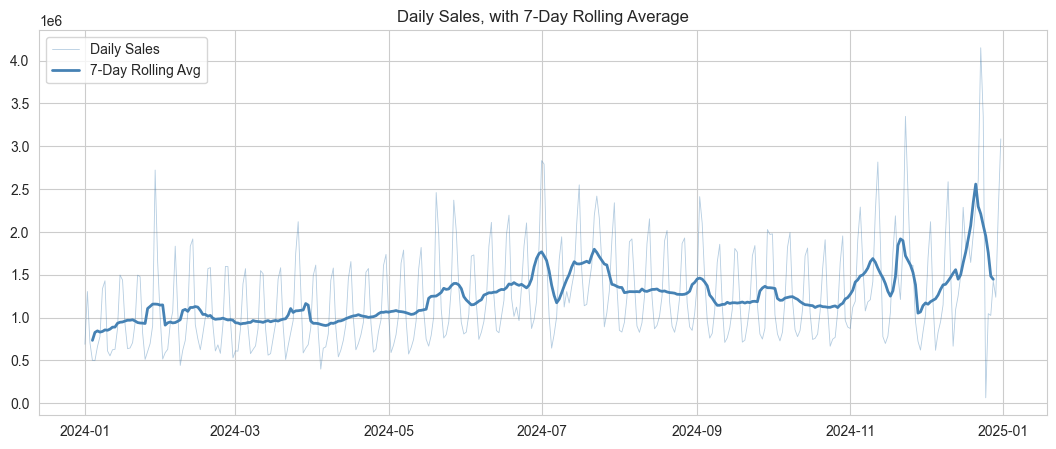

In [45]:
sales_daily['Sales7DayAvg'] = sales_daily['TotalSalesDollars'].rolling(7, center=True).mean()

plt.figure(figsize=(13, 5))
plt.plot(sales_daily['SalesDate'], sales_daily['TotalSalesDollars'], lw=0.6, alpha=0.4, color='steelblue', label='Daily Sales')
plt.plot(sales_daily['SalesDate'], sales_daily['Sales7DayAvg'], lw=2, color='steelblue', label='7-Day Rolling Avg')
plt.legend()
plt.title("Daily Sales, with 7-Day Rolling Average")
plt.show()

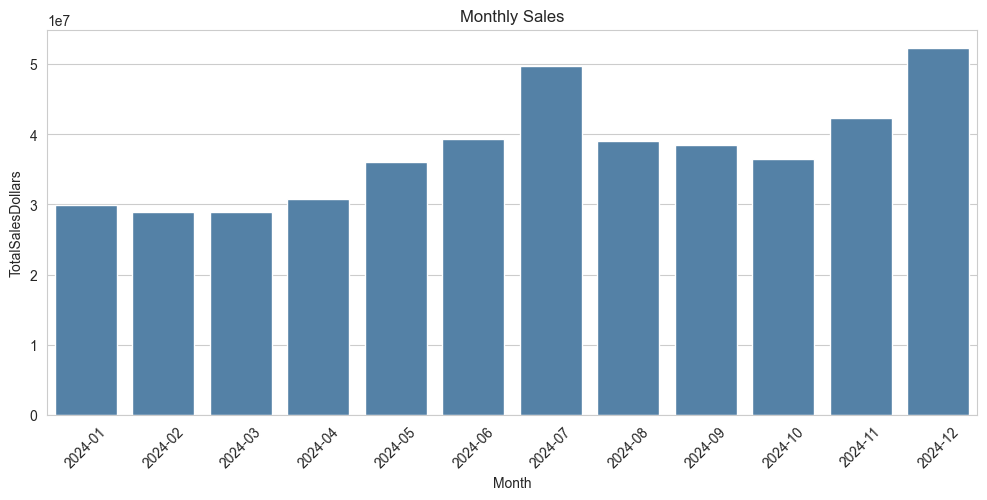

Highest sales month: 2024-12 ($52.31M)
Lowest sales month:  2024-02 ($28.88M)


In [46]:
sales_daily['Month'] = sales_daily['SalesDate'].dt.to_period('M').astype(str)
monthly_sales = sales_daily.groupby('Month')['TotalSalesDollars'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_sales, x='Month', y='TotalSalesDollars', color='steelblue')
plt.xticks(rotation=45)
plt.title("Monthly Sales")
plt.show()

best_month = monthly_sales.loc[monthly_sales['TotalSalesDollars'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['TotalSalesDollars'].idxmin()]
print(f"Highest sales month: {best_month['Month']} ({format_dollars(best_month['TotalSalesDollars'])})")
print(f"Lowest sales month:  {worst_month['Month']} ({format_dollars(worst_month['TotalSalesDollars'])})")

## 3.2 Cumulative sales trend across the year

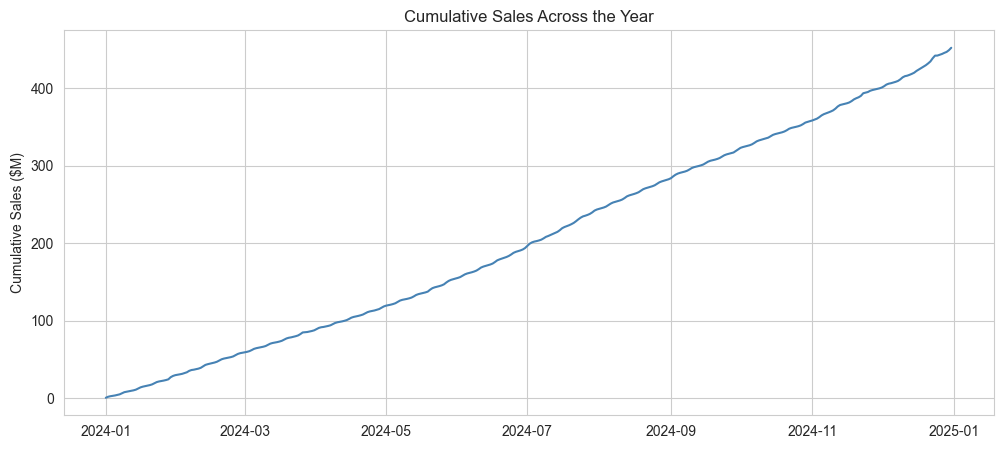

In [47]:
sales_daily['CumulativeSales'] = sales_daily['TotalSalesDollars'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(sales_daily['SalesDate'], sales_daily['CumulativeSales'] / 1e6, color='steelblue')
plt.ylabel("Cumulative Sales ($M)")
plt.title("Cumulative Sales Across the Year")
plt.show()

## 3.3 Day-of-week pattern: sales

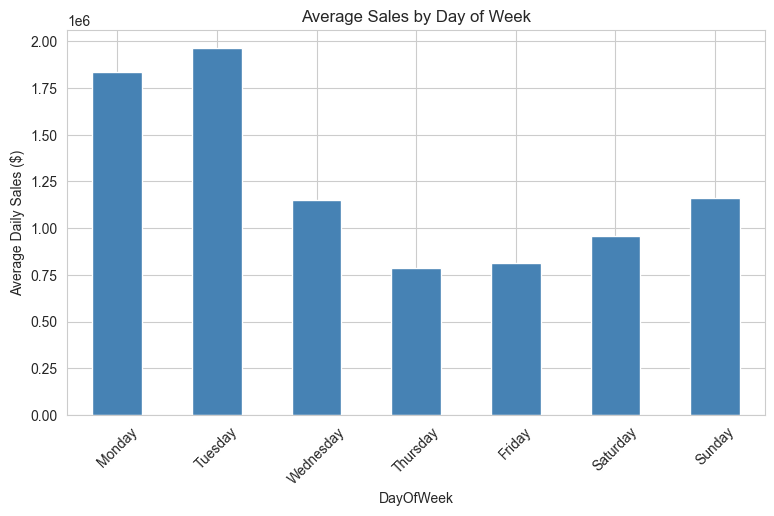

In [48]:
sales_daily['DayOfWeek'] = sales_daily['SalesDate'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = sales_daily.groupby('DayOfWeek')['TotalSalesDollars'].mean().reindex(dow_order)

plt.figure(figsize=(9, 5))
dow_sales.plot(kind='bar', color='steelblue')
plt.ylabel("Average Daily Sales ($)")
plt.title("Average Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

## 3.4 Day-of-week pattern: purchases received

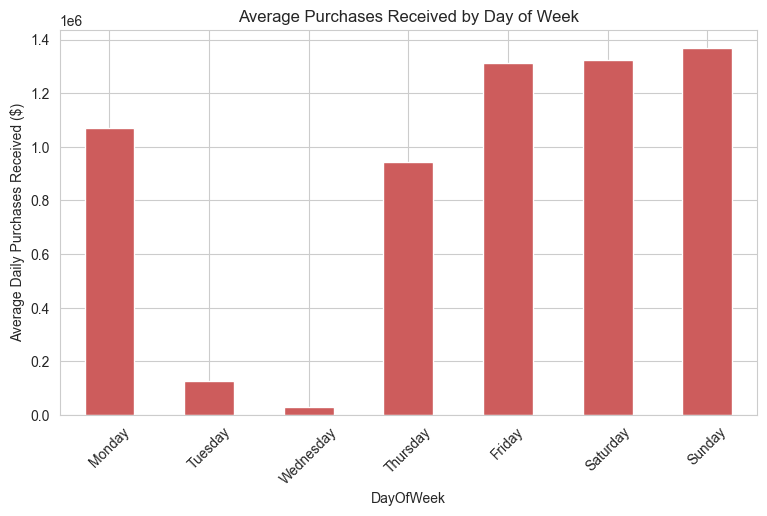

In [49]:
purchases_daily['DayOfWeek'] = purchases_daily['ReceivingDate'].dt.day_name()
dow_purchases = purchases_daily.groupby('DayOfWeek')['TotalPurchaseDollars'].mean().reindex(dow_order)

plt.figure(figsize=(9, 5))
dow_purchases.plot(kind='bar', color='indianred')
plt.ylabel("Average Daily Purchases Received ($)")
plt.title("Average Purchases Received by Day of Week")
plt.xticks(rotation=45)
plt.show()

**Finding:** this is a striking pattern. Almost no stock is received on Tuesdays (roughly 0.1 million dollars on average) or
Wednesdays (close to zero), while every other day averages roughly 0.9 to 1.4 million dollars in receiving. This looks like
deliveries clustering on specific days rather than noise.

## 3.5 Purchases over time, and how they compare to sales

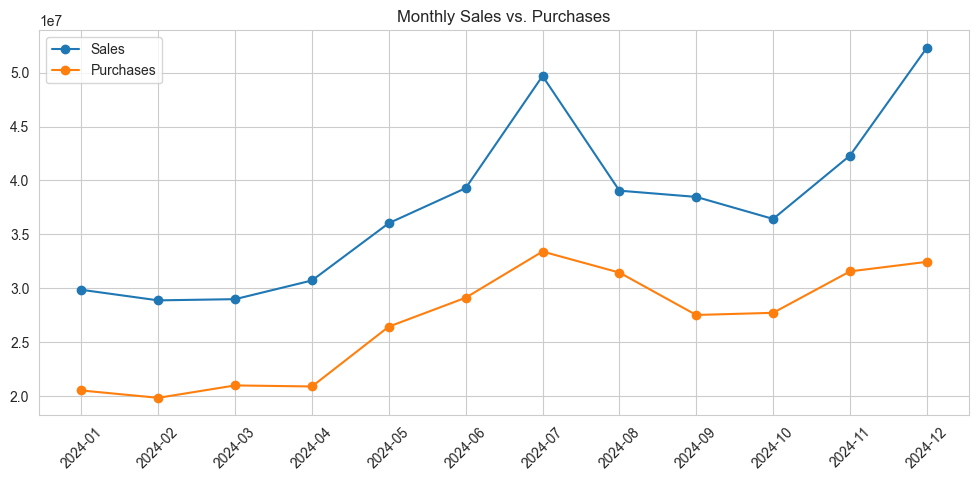

In [50]:
purchases_daily['Month'] = purchases_daily['ReceivingDate'].dt.to_period('M').astype(str)
monthly_purchases = purchases_daily.groupby('Month')['TotalPurchaseDollars'].sum().reset_index()
combined = monthly_sales.merge(monthly_purchases, on='Month', how='outer').sort_values('Month')

plt.figure(figsize=(12, 5))
plt.plot(combined['Month'], combined['TotalSalesDollars'], marker='o', label='Sales')
plt.plot(combined['Month'], combined['TotalPurchaseDollars'], marker='o', label='Purchases')
plt.xticks(rotation=45)
plt.legend()
plt.title("Monthly Sales vs. Purchases")
plt.show()

## 3.6 Promotions: how common are they?

In [51]:
promo_rows = int(sales_daily['PromoRows'].sum())
total_rows = int(sales_daily['RowCount'].sum())
promo_units = df['PromoSalesQuantity'].sum()
total_units = df['TotalSalesQuantity'].sum()

print(f"Promotional (free) transactions: {promo_rows:,} of {total_rows:,} total sales rows ({promo_rows / total_rows * 100:.5f}%)")
print(f"Promotional units: {promo_units:,.0f} of {total_units:,.0f} units sold ({promo_units / total_units * 100:.5f}%)")
print("Promotions are far too rare in this data to measure any effect on sales (there are only "
      f"{promo_rows} such transactions across the whole year), so no conclusion about their impact is drawn.")

Promotional (free) transactions: 55 of 12,825,463 total sales rows (0.00043%)
Promotional units: 103 of 32,906,378 units sold (0.00031%)
Promotions are far too rare in this data to measure any effect on sales (there are only 55 such transactions across the whole year), so no conclusion about their impact is drawn.


# 4. Store & City Performance

Grain: one row per Store. Source: `store_city_performance_summary`
(purchases + sales at Store grain, City attached via a lookup from the inventory tables).
Covers the geographic angle the "Vendor-Product Sales Summary" table can't show (Store isn't part of
that table's grain).

In [52]:
store = pd.read_sql_query("select * from store_city_performance_summary", engine)
store.head()

,Store,City,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,PromoSalesQuantity,GrossProfit,ProfitMargin,AvgSellingPrice,StockTurnover,SalesToPurchaseRatio
0,1,HARDERSFIELD,588498,4844714.06,558795,6669584.85,278517.14,0,1824870.79,27.36,11.94,0.9495,1.3767
1,2,ASHBORNE,421503,4504046.53,417757,6431522.53,299645.83,0,1927476.00,29.97,15.40,0.9911,1.4279
2,3,HORNSEY,35202,286621.82,35111,419732.96,9246.70,0,133111.14,31.71,11.95,0.9974,1.4644
3,4,EANVERNESS,273271,2247278.50,269520,3146860.80,156798.48,0,899582.30,28.59,11.68,0.9863,1.4003
4,5,SUTTON,127844,956212.60,124104,1334783.32,82603.12,0,378570.72,28.36,10.76,0.9707,1.3959


In [53]:
print(f"Stores: {len(store)}  |  Distinct cities: {store['City'].nunique()}")
store.describe().T

Stores: 80  |  Distinct cities: 68


,count,mean,std,min,25%,50%,75%,max
Store,80.0,4.051250e+01,2.325968e+01,1.0000,2.075000e+01,4.050000e+01,6.025000e+01,8.100000e+01
TotalPurchaseQuantity,80.0,4.198047e+05,3.326547e+05,35202.0000,2.005272e+05,3.258875e+05,4.622452e+05,1.576803e+06
TotalPurchaseDollars,80.0,4.023760e+06,3.693750e+06,286621.8200,1.729399e+06,2.919289e+06,4.438821e+06,1.752511e+07
TotalSalesQuantity,80.0,4.114760e+05,3.264679e+05,35111.0000,1.985735e+05,3.261735e+05,4.627378e+05,1.573145e+06
TotalSalesDollars,80.0,5.650836e+06,5.204159e+06,419732.9600,2.437670e+06,3.894813e+06,6.436562e+06,2.545154e+07
TotalExciseTax,80.0,2.371789e+05,1.780138e+05,9246.7000,1.241061e+05,1.950663e+05,2.812200e+05,8.589990e+05
PromoSalesQuantity,80.0,1.537500e+00,3.811853e+00,0.0000,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+01
GrossProfit,80.0,1.627076e+06,1.572905e+06,-807270.6200,6.857269e+05,1.146267e+06,1.794574e+06,7.926429e+06
ProfitMargin,80.0,2.798925e+01,1.369564e+01,-86.3400,2.868000e+01,2.982000e+01,3.092750e+01,5.207000e+01
AvgSellingPrice,80.0,1.295137e+01,1.356591e+00,10.6400,1.194750e+01,1.282000e+01,1.367000e+01,1.618000e+01


## 4.1 How is performance distributed across stores?

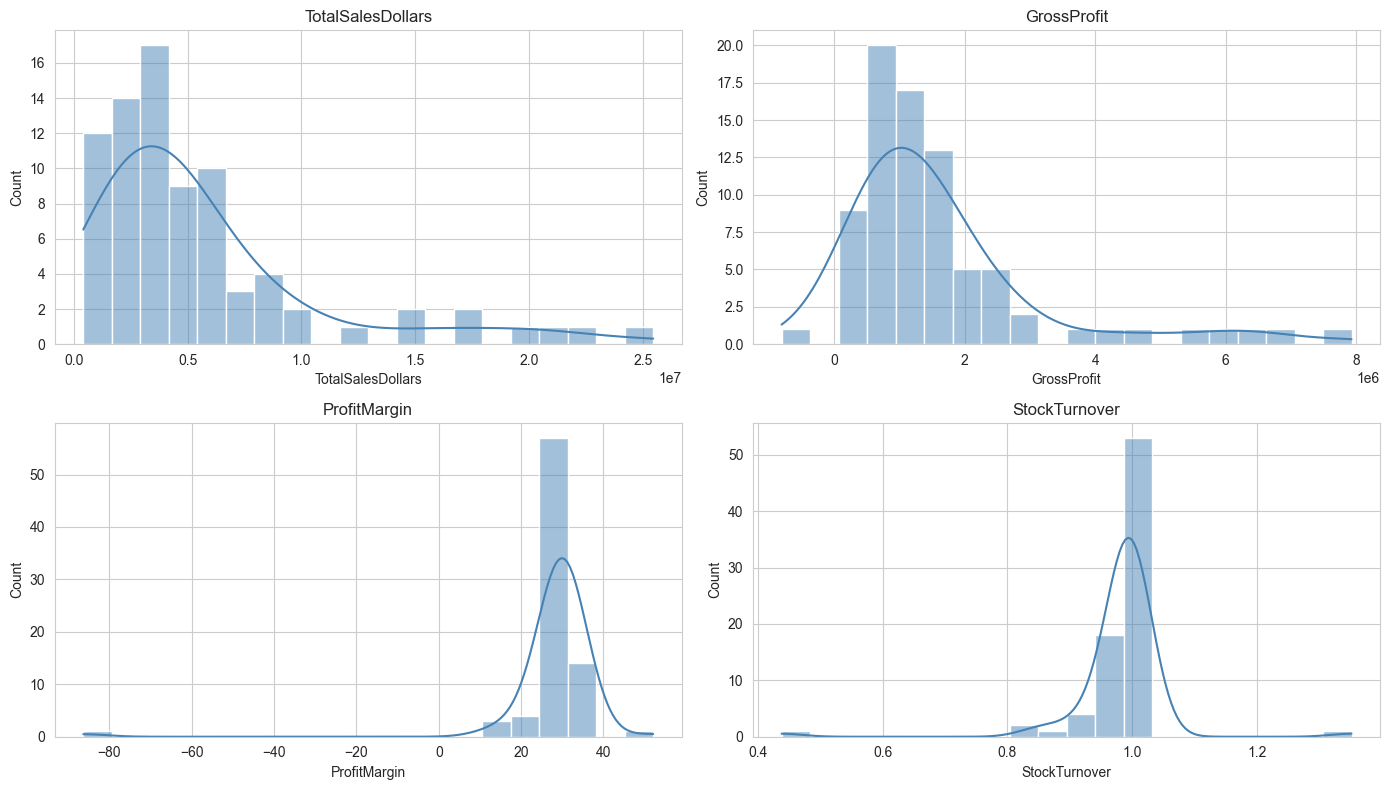

In [54]:
store_cols = ['TotalSalesDollars', 'GrossProfit', 'ProfitMargin', 'StockTurnover']

plt.figure(figsize=(14, 8))
for i, col in enumerate(store_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(store[col], kde=True, bins=20, color='steelblue')
    plt.title(col)
plt.tight_layout()
plt.show()

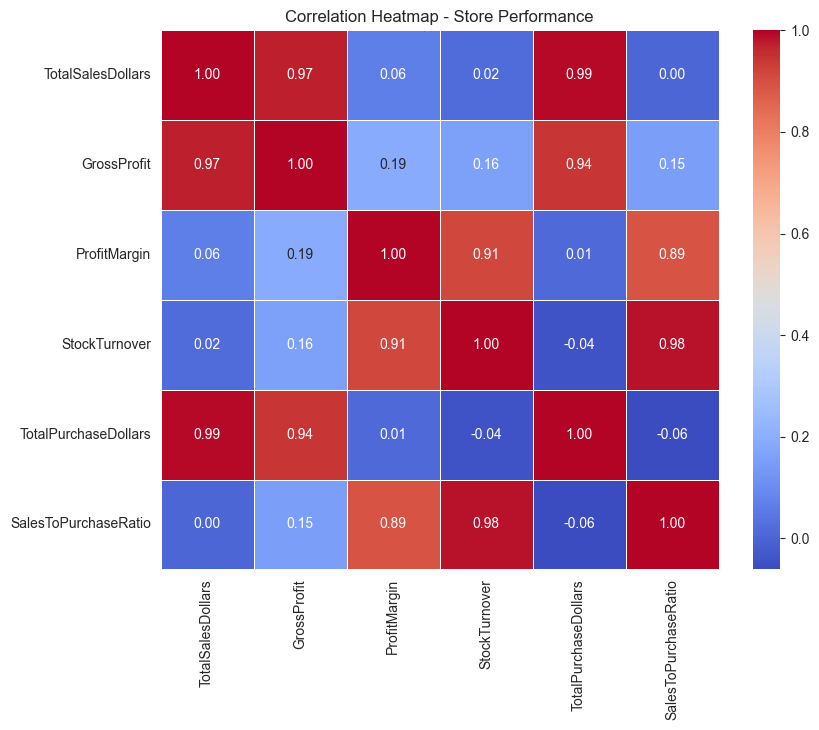

In [55]:
plt.figure(figsize=(9, 7))
sns.heatmap(store[store_cols + ['TotalPurchaseDollars', 'SalesToPurchaseRatio']].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Store Performance")
plt.show()

## 4.2 Top and bottom stores by sales and profit margin

In [56]:
# Some cities have several stores (e.g. 4 in MOUNTMEND), so charts are labelled with Store + City
# to avoid identical-looking bars.
store['StoreLabel'] = 'Store ' + store['Store'].astype(str) + ' (' + store['City'] + ')'

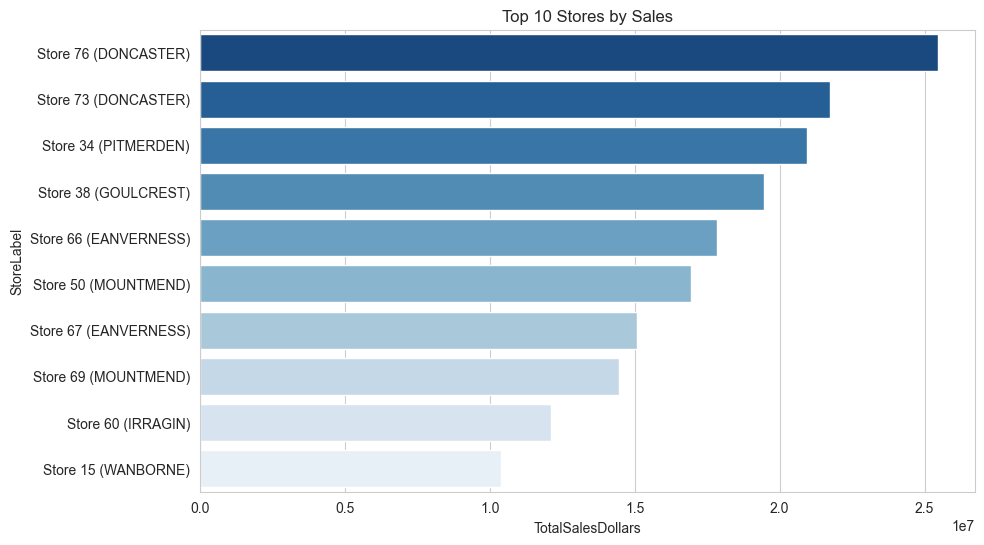

In [57]:
# Top 10 stores by Sales
top_sales = store.sort_values('TotalSalesDollars', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_sales, y='StoreLabel', x='TotalSalesDollars', palette="Blues_r")
plt.title("Top 10 Stores by Sales")
plt.show()

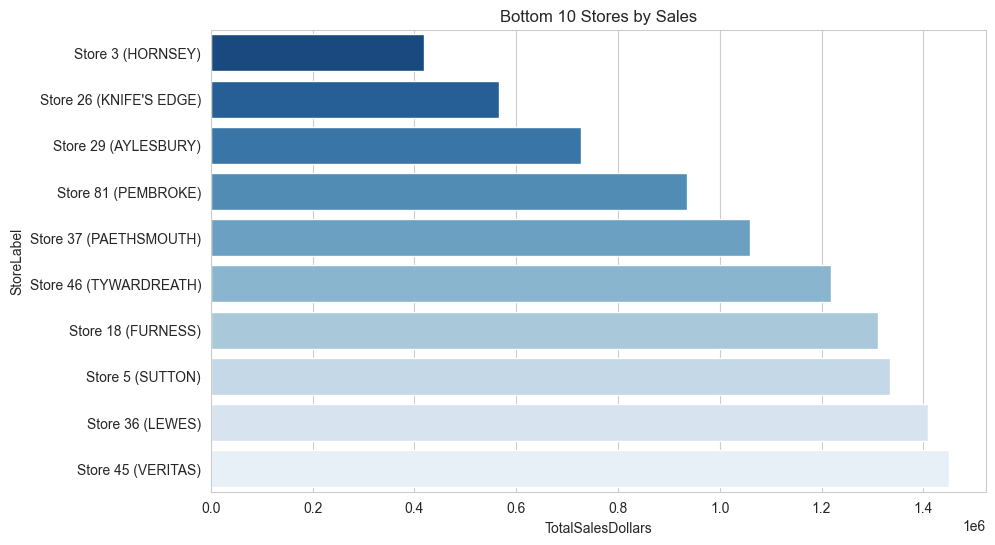

In [58]:
# Bottom 10 stores by Sales
bottom_sales = store[store['TotalSalesDollars'] > 0].sort_values('TotalSalesDollars', ascending=True).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_sales, y='StoreLabel', x='TotalSalesDollars', palette='Blues_r')
plt.title("Bottom 10 Stores by Sales")
plt.show()

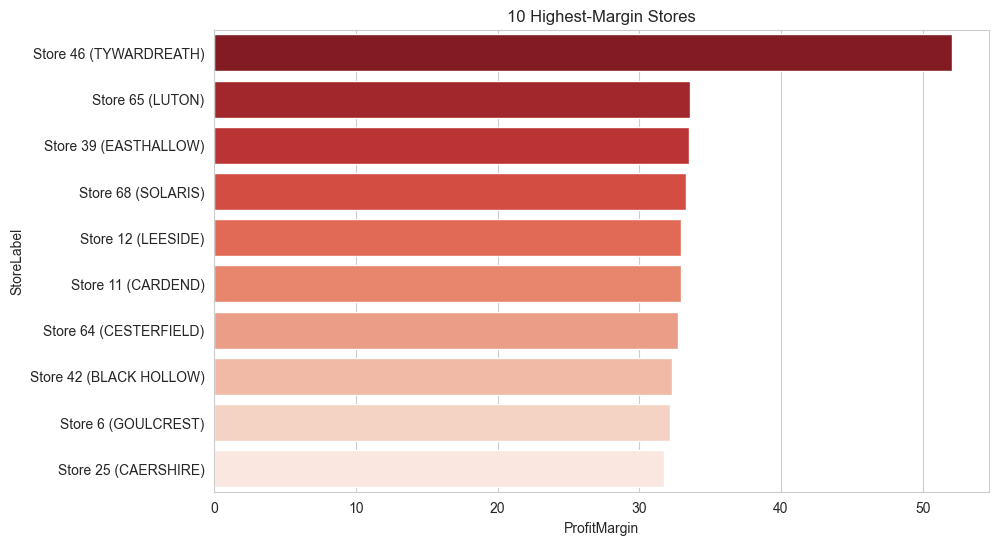

In [59]:
# Top 10 stores by Profit Margin
top_margin = store[store['TotalSalesDollars'] > 0].sort_values('ProfitMargin', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_margin, y='StoreLabel', x='ProfitMargin', palette='Reds_r')
plt.title("10 Highest-Margin Stores")
plt.show()

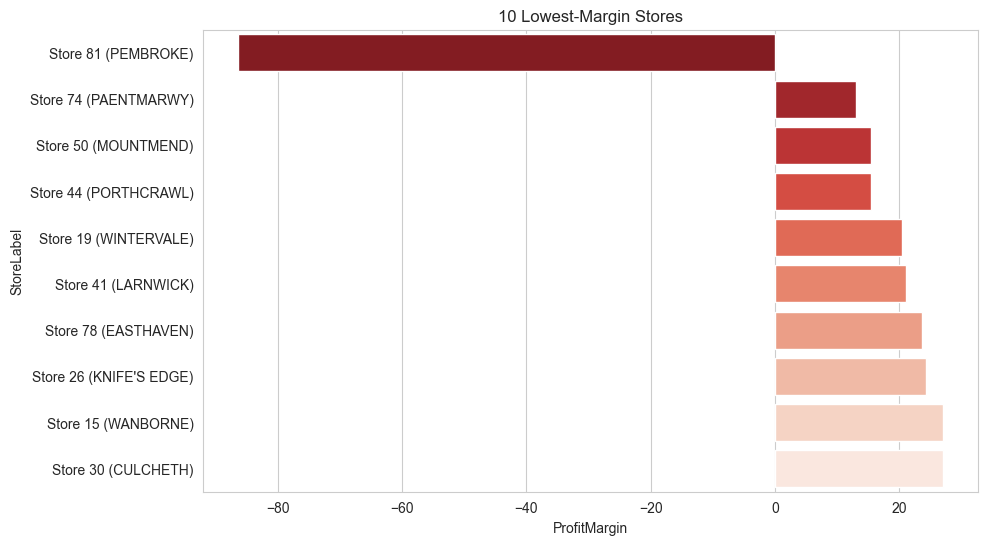

In [60]:
# Bottom 10 stores by Profit Margin
bottom_margin = store[store['TotalSalesDollars'] > 0].sort_values('ProfitMargin').head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_margin, y='StoreLabel', x='ProfitMargin', palette="Reds_r")
plt.title("10 Lowest-Margin Stores")
plt.show()

**Finding:** Store 81 stands out with a profit margin of about -86%, far below every other store (the next lowest stores sit
at roughly 13% to 21%). Store 81 is also the store with 3,589 new products and no discontinued ones (Section 5.4), which is
consistent with a store that opened during the year and bought its opening stock before sales caught up. The same pattern
appears more broadly: the five stores with the most new products (Stores 50, 81, 74, 41 and 44, Section 5.4) all appear
among the lowest-margin stores here. Their low margins may therefore reflect new or expanding stores rather than weak
trading, which should be confirmed against store opening dates.

## 4.3 City-level rollup

In [61]:
city_agg = store.groupby('City').agg(
    StoreCount=('Store', 'count'),
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).sort_values('TotalSalesDollars', ascending=False)
city_agg['ProfitMargin'] = city_agg['GrossProfit'] / city_agg['TotalSalesDollars'] * 100

print(f"Cities with more than 1 store: {(city_agg['StoreCount'] > 1).sum()}")
city_agg.head(10)

Cities with more than 1 store: 7


,StoreCount,TotalSalesDollars,GrossProfit,ProfitMargin
City,,,,
DONCASTER,2,47187510.31,14594447.21,30.928623
MOUNTMEND,4,41736193.98,9921850.49,23.772773
EANVERNESS,3,36070579.57,11144802.89,30.897210
GOULCREST,2,25903323.15,8011948.94,30.930197
PITMERDEN,1,20928718.38,6468550.42,30.907532
HORNSEY,4,19048572.55,5611397.60,29.458363
IRRAGIN,1,12123848.60,3698781.86,30.508314
HARDERSFIELD,2,11335894.49,3239877.89,28.580699
LARNWICK,2,10841496.30,2419971.27,22.321377


## 4.4 Store size vs. profit margin

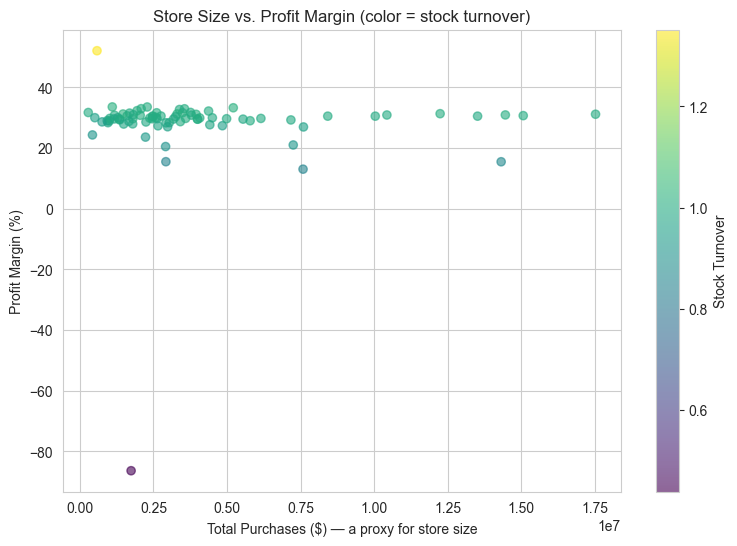

In [62]:
plt.figure(figsize=(9, 6))
plt.scatter(store['TotalPurchaseDollars'], store['ProfitMargin'], alpha=0.6, c=store['StockTurnover'], cmap='viridis')
plt.xlabel("Total Purchases ($) — a proxy for store size")
plt.ylabel("Profit Margin (%)")
plt.title("Store Size vs. Profit Margin (color = stock turnover)")
plt.colorbar(label='Stock Turnover')
plt.show()

**Finding:** Store size and profit margin do not have a strong relationship. Some smaller stores have higher profit margins than larger stores, so each store may need to be looked at separately.

# 5. Inventory Reconciliation

Grain: one row per (Store, ProductID). Source: `inventory_reconciliation_summary`
(begin_inventory + end_inventory + purchases + sales, enriched with product_master).
Covers stockouts, shrinkage, and new/discontinued SKUs. `ExpectedEndQty = BeginQty +
TotalPurchaseQuantity - TotalSalesQuantity`; `Variance = EndQty - ExpectedEndQty`.

In [63]:
inv = pd.read_sql_query("select * from inventory_reconciliation_summary", engine)
print(f"Rows (Store x Product): {len(inv):,}")
print(f"New products (in end_inventory only): {inv['IsNewProduct'].sum():,}")
print(f"Discontinued products (in begin_inventory only): {inv['IsDiscontinued'].sum():,}")
inv['Variance'].describe()

Rows (Store x Product): 254,835
New products (in end_inventory only): 48,306
Discontinued products (in begin_inventory only): 30,346


count    254835.000000
mean          0.000812
std           0.121837
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          36.000000
Name: Variance, dtype: float64

## 5.1 Did overall inventory across all stores grow or shrink over the year?

The net change below includes products that appear in only one snapshot: new products (in the end-of-year inventory
only) add units, and discontinued products (in the start-of-year inventory only) remove them.

Total units, start of year: 4,219,275
Total units, end of year:   4,885,776
Net change: 666,501 units (15.8%)


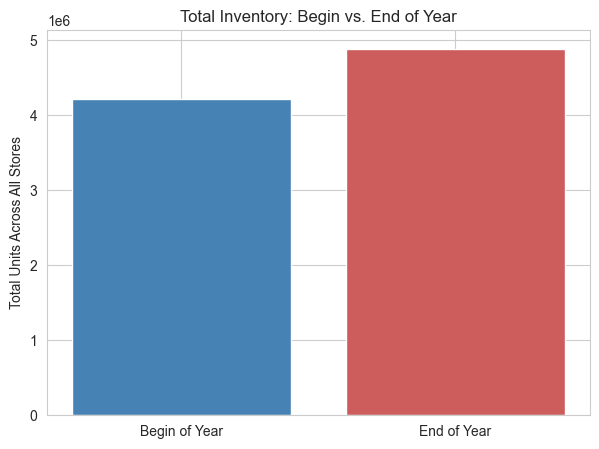

In [64]:
total_begin = inv['BeginQty'].sum()
total_end = inv['EndQty'].sum()
print(f"Total units, start of year: {total_begin:,.0f}")
print(f"Total units, end of year:   {total_end:,.0f}")
print(f"Net change: {total_end - total_begin:,.0f} units ({((total_end - total_begin)/total_begin)*100:.1f}%)")

plt.figure(figsize=(7, 5))
plt.bar(['Begin of Year', 'End of Year'], [total_begin, total_end], color=['steelblue', 'indianred'])
plt.ylabel("Total Units Across All Stores")
plt.title("Total Inventory: Begin vs. End of Year")
plt.show()

## 5.2 How much of the inventory reconciles cleanly?

Rows where EndQty exactly matches ExpectedEndQty: 99.9902%
Rows with a non-zero variance: 25 of 254,835
Total variance: 207 units  |  largest single row: 36  |  smallest: 0

Largest variances (Variance = EndQty - ExpectedEndQty; positive means more stock than the records explain):


,Store,ProductID,ProductName,VendorName,BeginQty,TotalPurchaseQuantity,TotalSalesQuantity,EndQty,ExpectedEndQty,Variance
145,1,1024,Hennessey VS +VSOP 50mL,MOET HENNESSY USA INC,53,6,95,0,-36,36
2225,1,10238,Layer Cake Primitivo Puglia,MARTIGNETTI COMPANIES,14,223,245,19,-8,27
2226,1,10239,Cannonball Cab Svgn Cal,MARTIGNETTI COMPANIES,14,127,141,22,0,22
2222,1,10062,Terroirs du Rhone,PERFECTA WINES,23,97,109,29,11,18
2221,1,10058,F Coppola Dmd Ivry Cab Svgn,SOUTHERN GLAZERS W&S OF NE,21,395,384,47,32,15
2228,1,10264,Fort Ross Pnt Nr Sonoma Cst,PERFECTA WINES,26,0,38,0,-12,12
142,1,1021,St Brendans Peppermint Bark,LUXCO INC,12,0,24,0,-12,12
2229,1,10266,Klinker Brick Old Vine Znfdl,M S WALKER INC,12,266,223,66,55,11
2224,1,10236,Layer Cake Malbec Mendoza,MARTIGNETTI COMPANIES,1,411,344,79,68,11
2230,1,10296,Alamos Slcn Malbec Mendoza,E & J GALLO WINERY,0,117,103,23,14,9


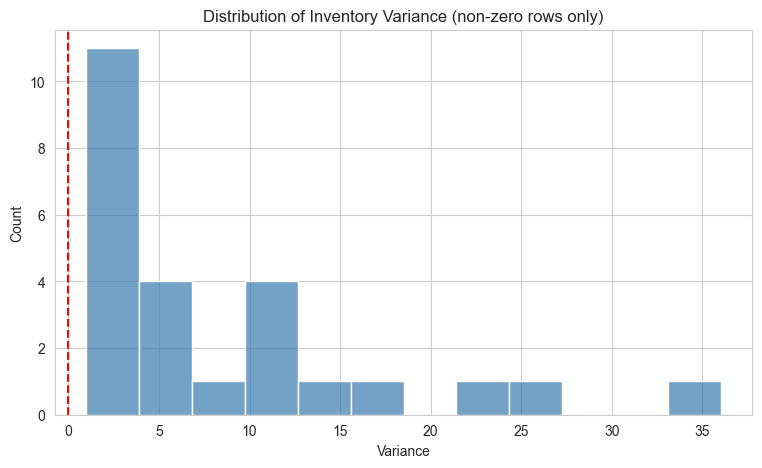

In [65]:
nonzero = inv[inv['Variance'] != 0]
exact_match = (inv['Variance'] == 0).mean() * 100

print(f"Rows where EndQty exactly matches ExpectedEndQty: {exact_match:.4f}%")
print(f"Rows with a non-zero variance: {len(nonzero):,} of {len(inv):,}")
print(f"Total variance: {inv['Variance'].sum():,.0f} units  |  largest single row: {inv['Variance'].max():,.0f}  |  smallest: {inv['Variance'].min():,.0f}")

if len(nonzero) > 0:
    print("\nLargest variances (Variance = EndQty - ExpectedEndQty; positive means more stock than the records explain):")
    display(nonzero.sort_values('Variance', ascending=False).head(10)[
        ['Store', 'ProductID', 'ProductName', 'VendorName', 'BeginQty',
         'TotalPurchaseQuantity', 'TotalSalesQuantity', 'EndQty', 'ExpectedEndQty', 'Variance']])

    plt.figure(figsize=(9, 5))
    sns.histplot(nonzero['Variance'], bins=min(40, max(5, int(nonzero['Variance'].nunique()))), color='steelblue')
    plt.axvline(0, color='red', ls='--')
    plt.title("Distribution of Inventory Variance (non-zero rows only)")
    plt.show()

**Note:** 99.9902% of Store-Product records reconcile exactly (254,810 of 254,835 records). Only 25 records have a non-zero variance, with the largest difference being 36 units. All 25 variances are positive, meaning actual ending inventory is higher than the calculated expected ending inventory for these records.

In four of the ten largest cases listed above, `ExpectedEndQty` is negative: recorded sales exceeded beginning stock plus purchases. That points to receipts or stock movements missing from the purchase data, rather than to shrinkage.

## 5.3 New vs. discontinued products, by vendor

In [66]:
lifecycle_by_vendor = inv.groupby('VendorName').agg(
    NewProducts=('IsNewProduct', 'sum'),
    DiscontinuedProducts=('IsDiscontinued', 'sum')
)
print("Most new products introduced, by vendor:")
display(lifecycle_by_vendor.sort_values('NewProducts', ascending=False).head(10))
print("\nMost discontinued products, by vendor:")
display(lifecycle_by_vendor.sort_values('DiscontinuedProducts', ascending=False).head(10))

Most new products introduced, by vendor:


,NewProducts,DiscontinuedProducts
VendorName,,
MARTIGNETTI COMPANIES,6039,3420
ULTRA BEVERAGE COMPANY LLP,4662,2911
PERFECTA WINES,3777,1397
M S WALKER INC,3238,1991
JIM BEAM BRANDS COMPANY,2157,1799
DIAGEO NORTH AMERICA INC,2093,2261
E & J GALLO WINERY,1982,740
CONSTELLATION BRANDS INC,1823,1211
PINE STATE TRADING CO,1719,1161



Most discontinued products, by vendor:


,NewProducts,DiscontinuedProducts
VendorName,,
MARTIGNETTI COMPANIES,6039,3420
ULTRA BEVERAGE COMPANY LLP,4662,2911
DIAGEO NORTH AMERICA INC,2093,2261
M S WALKER INC,3238,1991
JIM BEAM BRANDS COMPANY,2157,1799
PERFECTA WINES,3777,1397
BACARDI USA INC,880,1291
CONSTELLATION BRANDS INC,1823,1211
PINE STATE TRADING CO,1719,1161


## 5.4 New vs. discontinued products, by store

In [67]:
lifecycle_by_store = inv.groupby('Store').agg(
    NewProducts=('IsNewProduct', 'sum'),
    DiscontinuedProducts=('IsDiscontinued', 'sum')
)

print("Most new products introduced, by store:")
display(
    lifecycle_by_store
    .sort_values('NewProducts', ascending=False)
    .head(10)
)

print("\nMost discontinued products, by store:")
display(
    lifecycle_by_store
    .sort_values('DiscontinuedProducts', ascending=False)
    .head(10)
)

Most new products introduced, by store:


,NewProducts,DiscontinuedProducts
Store,,
50,3769,329
81,3589,0
74,3130,143
41,2314,222
44,1763,197
34,1340,924
69,1236,912
73,1176,972
67,1163,1201



Most discontinued products, by store:


,NewProducts,DiscontinuedProducts
Store,,
67,1163,1201
66,1113,1187
76,1090,1085
73,1176,972
34,1340,924
69,1236,912
38,1131,886
60,825,800
33,822,787


**Finding:** Stores differ a lot in how many new and discontinued products they have. Some stores add many new products
with very few discontinued products, while others have a more balanced mix. This may be due to store expansion or
differences in product management. For example, Store 81 shows 3,589 new products and none discontinued, which is
consistent with a store that opened during the year; this should be confirmed against store records.

## 5.5 Did product prices change between the start and end of the year?

`BeginSalesPrice`/`EndSalesPrice` are the catalog price at each inventory snapshot (Jan 1 vs.
Dec 31) for the same Store-Product. Comparing them shows real price movement over the year,
separate from the quantity-based reconciliation above.

In [68]:
both_prices = inv.dropna(subset=['BeginSalesPrice', 'EndSalesPrice']).copy()
both_prices['PriceChange'] = both_prices['EndSalesPrice'] - both_prices['BeginSalesPrice']

pct_changed = (both_prices['PriceChange'] != 0).mean() * 100
print(f"Store-Product rows with both snapshots present: {len(both_prices):,}")
print(f"Of those, price changed at all: {pct_changed:.1f}%")
both_prices['PriceChange'].describe()

Store-Product rows with both snapshots present: 176,183
Of those, price changed at all: 29.6%


count    176183.000000
mean          0.103086
std           2.489317
min         -40.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         260.000000
Name: PriceChange, dtype: float64

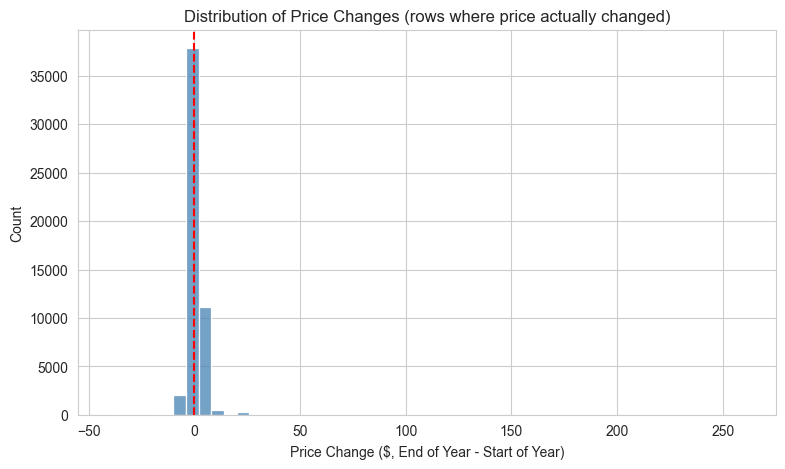

In [69]:
plt.figure(figsize=(9, 5))
sns.histplot(both_prices.loc[both_prices['PriceChange'] != 0, 'PriceChange'], bins=50, color='steelblue')
plt.axvline(0, color='red', ls='--')
plt.xlabel("Price Change ($, End of Year - Start of Year)")
plt.title("Distribution of Price Changes (rows where price actually changed)")
plt.show()

In [70]:
biggest_increases = both_prices.sort_values('PriceChange', ascending=False).head(10)
biggest_cuts = both_prices.sort_values('PriceChange').head(10)

print("Biggest price increases:")
display(biggest_increases[['Store','ProductID','ProductName','BeginSalesPrice','EndSalesPrice','PriceChange']])
print("\nBiggest price cuts:")
display(biggest_cuts[['Store','ProductID','ProductName','BeginSalesPrice','EndSalesPrice','PriceChange']])

Biggest price increases:


,Store,ProductID,ProductName,BeginSalesPrice,EndSalesPrice,PriceChange
90919,34,368,The Macallan 25 Yr Old,1299.99,1559.99,260.0
236301,76,368,The Macallan 25 Yr Old,1299.99,1559.99,260.0
173266,60,368,The Macallan 25 Yr Old,1299.99,1559.99,260.0
196738,67,368,The Macallan 25 Yr Old,1299.99,1559.99,260.0
236310,76,423,Hennessy Richard Cognac,4559.99,4696.99,137.0
190668,66,423,Hennessy Richard Cognac,4559.99,4696.99,137.0
222149,73,423,Hennessy Richard Cognac,4559.99,4696.99,137.0
90930,34,423,Hennessy Richard Cognac,4559.99,4696.99,137.0
196748,67,423,Hennessy Richard Cognac,4559.99,4696.99,137.0
222908,73,2842,Laphroaig 25 Yr Cask Strenth,399.99,499.99,100.0



Biggest price cuts:


,Store,ProductID,ProductName,BeginSalesPrice,EndSalesPrice,PriceChange
8740,4,4652,Hennessy XO Cognac,199.99,159.99,-40.0
248421,79,4652,Hennessy XO Cognac,199.99,159.99,-40.0
48023,18,4652,Hennessy XO Cognac,199.99,159.99,-40.0
192215,66,4652,Hennessy XO Cognac,199.99,159.99,-40.0
83960,32,4652,Hennessy XO Cognac,199.99,159.99,-40.0
142097,50,4652,Hennessy XO Cognac,199.99,159.99,-40.0
40806,15,4652,Hennessy XO Cognac,199.99,159.99,-40.0
174736,60,4652,Hennessy XO Cognac,199.99,159.99,-40.0
55654,21,4652,Hennessy XO Cognac,199.99,159.99,-40.0
217594,71,4652,Hennessy XO Cognac,199.99,159.99,-40.0


**Finding:** About 30% of Store-Product combinations had a price change during the year. The price changes ranged from a 40 dollars decrease to a 260 dollars increase. This shows that product prices changed at some stores during the year.

# 6. Dead-Stock Analysis

Products purchased but never sold (`TotalSalesQuantity = 0`). Kept as rows in
`vendor_product_sales_summary` (flagged `IsDeadStock`) instead of being filtered out, so
they're analyzed here directly instead of silently discarded.

In [71]:
dead_stock = df[df['IsDeadStock'] == 1]
print(f"Dead-stock products: {len(dead_stock)} of {len(df)} ({len(dead_stock)/len(df)*100:.1f}%)")
print("Capital tied up:", format_dollars(dead_stock['TotalPurchaseDollars'].sum()))
print("Of which free samples (IsFreeSample=1, $0 capital at risk):", dead_stock['IsFreeSample'].sum())

Dead-stock products: 178 of 10693 (1.7%)
Capital tied up: $282.18K
Of which free samples (IsFreeSample=1, $0 capital at risk): 0


## 6.1 Which vendors have the most dead stock, in actual dollars?

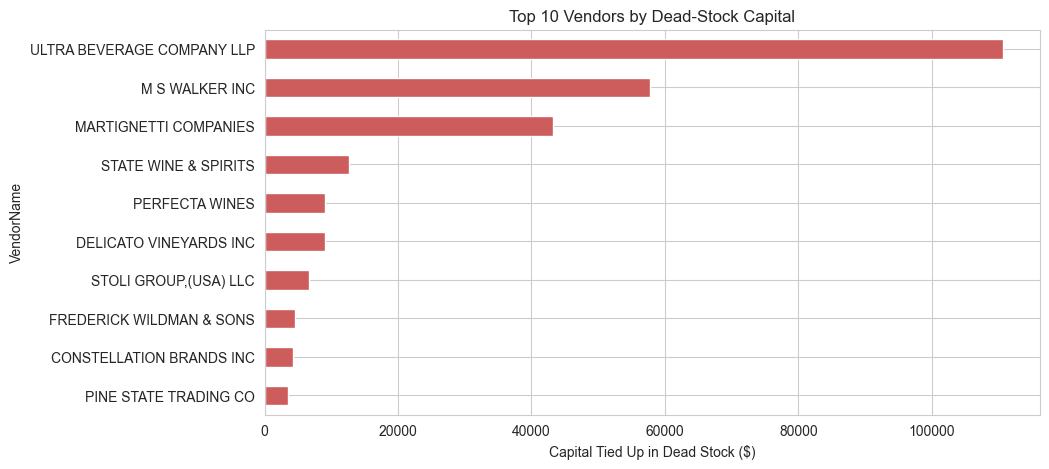

In [72]:
dead_by_vendor = dead_stock.groupby('VendorName')['TotalPurchaseDollars'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dead_by_vendor.head(10).plot(kind='barh', color='indianred')
plt.gca().invert_yaxis()
plt.xlabel("Capital Tied Up in Dead Stock ($)")
plt.title("Top 10 Vendors by Dead-Stock Capital")
plt.show()

## 6.2 Which vendors have the highest dead-stock *rate*?

In [73]:
# Absolute dead-stock dollars which are calculated above, favors large vendors because they have more products.(More Products = More Dead Stock)
# Dead-stock rate shows what percentage of a vendor's products are dead stock.
# This gives a fairer comparison between vendors of different sizes.
vendor_dead_rate = df.groupby('VendorName').agg(
    TotalProducts=('ProductID', 'count'),
    DeadProducts=('IsDeadStock', 'sum')
).query('TotalProducts >= 5')
vendor_dead_rate['DeadRate%'] = vendor_dead_rate['DeadProducts'] / vendor_dead_rate['TotalProducts'] * 100

print("Highest dead-stock rate (vendors with 5+ products):")
vendor_dead_rate.sort_values('DeadRate%', ascending=False).head(10)

Highest dead-stock rate (vendors with 5+ products):


,TotalProducts,DeadProducts,DeadRate%
VendorName,,,
HIGHLAND WINE MERCHANTS LLC,11,5,45.454545
MILTONS DISTRIBUTING CO,18,4,22.222222
SURVILLE ENTERPRISES CORP,21,2,9.523810
VINEXTRA INC,32,3,9.375000
STELLAR IMPORTING CO LLC,18,1,5.555556
PINE STATE TRADING CO,422,22,5.213270
CRUSH WINES,139,7,5.035971
Circa Wines,66,3,4.545455
PHILLIPS PRODUCTS CO.,23,1,4.347826


**Finding:** The vendors with the highest dead-stock rate are different from those with the highest dead-stock dollar value. Smaller vendors may have a high percentage of products that are unsold, even if their total dead-stock dollar value is low.

## 6.3 Does dead stock concentrate in specific bottle sizes or classifications?

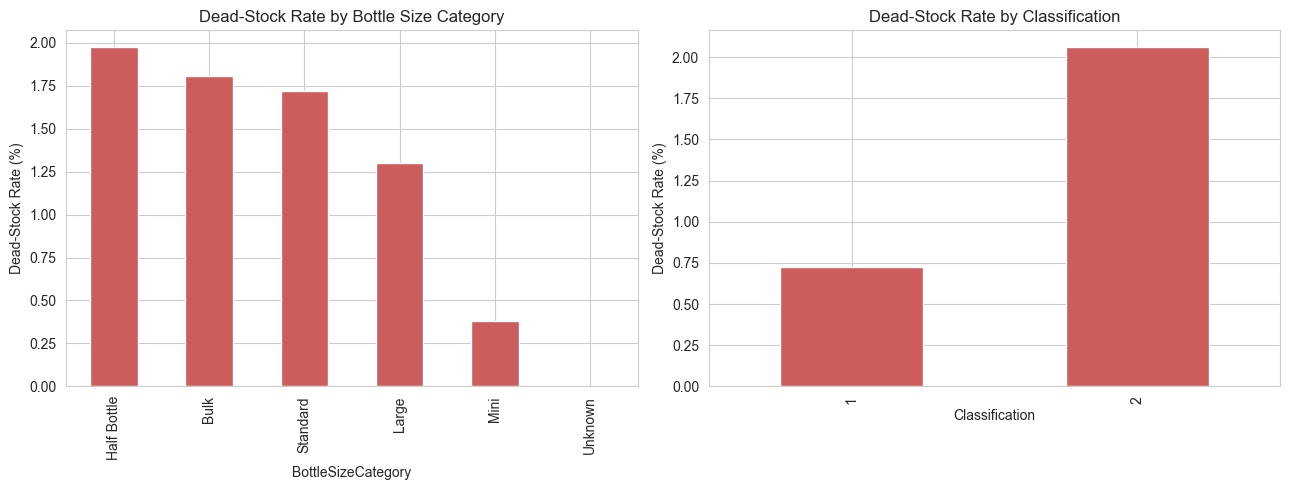

In [74]:
dead_by_format = df.groupby('BottleSizeCategory')['IsDeadStock'].mean() * 100
dead_by_class = df.groupby('Classification')['IsDeadStock'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dead_by_format.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_ylabel("Dead-Stock Rate (%)")
axes[0].set_title("Dead-Stock Rate by Bottle Size Category")

dead_by_class.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_ylabel("Dead-Stock Rate (%)")
axes[1].set_title("Dead-Stock Rate by Classification")
plt.tight_layout()
plt.show()

**Finding:** dead-stock rates are low everywhere, but Classification 2 is noticeably higher: about 2.1% of its vendor-product
lines are dead stock, versus about 0.7% for Classification 1 (roughly 155 of 7,526 lines versus 23 of 3,167). By bottle size
the rates run from 0.4% for Mini to 2.0% for Half Bottle, with Bulk at 1.8%, Standard at 1.7% and Large at 1.3%, and
`Unknown` has none. The bottle-size differences rest on very few products (for example about 1 dead product in Mini and 3
in Bulk), so they should not be over-read. Standard accounts for most dead-stock products simply because it is by far the
largest format.

## 6.4 Most capital tied individual dead-stock products

In [75]:
dead_stock.sort_values('TotalPurchaseDollars', ascending=False).head(10)[
    ['VendorName', 'ProductName', 'PurchasePrice', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'IsFreeSample']
]

,VendorName,ProductName,PurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,IsFreeSample
6461,ULTRA BEVERAGE COMPANY LLP,Spade&Bushel 10yr Irish Wsky,29.84,804,23991.36,0
6464,ULTRA BEVERAGE COMPANY LLP,Brothership Whiskey,39.99,570,22794.30,0
6587,ULTRA BEVERAGE COMPANY LLP,Patron En Lalique Tequila,5681.81,3,17045.43,0
6462,ULTRA BEVERAGE COMPANY LLP,Straw Boys Vodka,14.70,1140,16758.00,0
7359,M S WALKER INC,Tamdhu Batch Speyside Whisky,72.46,228,16520.88,0
7979,M S WALKER INC,Ch Puech-Haut Prestige Langu,12.41,1008,12509.28,0
7356,M S WALKER INC,Tamdhu 10Yr Speyside Whiskey,53.48,228,12193.44,0
502,STATE WINE & SPIRITS,Aviary Cab Svgn,11.61,1017,11807.37,0
7163,ULTRA BEVERAGE COMPANY LLP,Killibinbin Sneaky Shiraz,10.20,1044,10648.80,0
4162,MARTIGNETTI COMPANIES,Hundred Acre Kayli Morgan,307.18,30,9215.40,0


## 6.5 Dead stock, at the store level

Everything above defines "dead stock" as a product with **zero sales across the entire
company** all year. But a product can sell perfectly well overall while still sitting
completely unsold at a *specific* store, a different, and much larger, problem. Checked
directly here using `inventory_reconciliation_summary` (which has sales at the
Store+ProductID grain, unlike the company-wide summary table).

In [76]:
inv['StoreLevelDead'] = (inv['TotalSalesQuantity'] == 0) & ((inv['BeginQty'] + inv['TotalPurchaseQuantity']) > 0)

company_wide_dead_ids = set(dead_stock['ProductID'])
store_level_dead_ids = set(inv.loc[inv['StoreLevelDead'], 'ProductID'])

print(f"Products dead company-wide (zero sales everywhere): {len(company_wide_dead_ids)}")
print(f"Products dead in at least one store (may sell fine elsewhere): {len(store_level_dead_ids)}")
print(f"Of those, dead locally but NOT on the company-wide list: {len(store_level_dead_ids - company_wide_dead_ids)}")

Products dead company-wide (zero sales everywhere): 178
Products dead in at least one store (may sell fine elsewhere): 2556
Of those, dead locally but NOT on the company-wide list: 2378


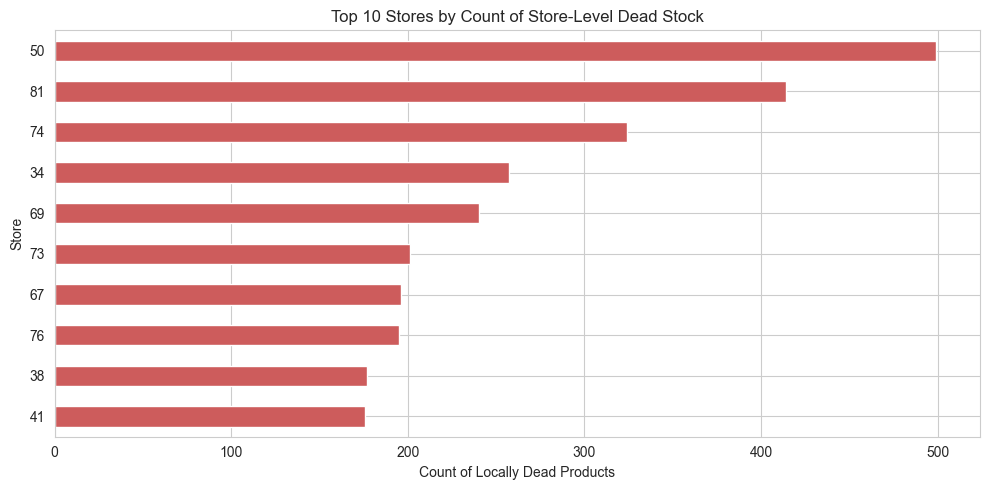

In [77]:
dead_by_store = inv.groupby('Store')['StoreLevelDead'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dead_by_store.head(10).plot(kind='barh', color='indianred')
plt.gca().invert_yaxis()
plt.xlabel("Count of Locally Dead Products")
plt.title("Top 10 Stores by Count of Store-Level Dead Stock")
plt.tight_layout()
plt.show()

**Finding:** the store-level analysis flags far more products (2,556) than the company-wide view (178), although this
compares product counts, not dollar value. Many of these products may still sell well at other stores but are not
selling at certain stores. This suggests that moving stock between stores or changing the product mix at specific stores
may help.

In [78]:
# Supporting numbers for the executive summary below (all recalculated from the data above).
print("VENDOR CONCENTRATION")
print(f"  Top 10 vendors by purchases: {top_vendors['Purchase_Contribution%'].sum():.1f}% of purchases, "
      f"{purchase_top10['TotalSalesDollars'].sum() / total_sales_all * 100:.1f}% of sales, "
      f"{purchase_top10['GrossProfit'].sum() / total_profit_all * 100:.1f}% of gross profit")
print("\nSALES-WEIGHTED MARGIN BY SEGMENT (company-wide: %.2f%%)" % overall_margin)
for name, table in [('Bottle size', format_performance), ('Classification', class_performance)]:
    for idx, row in table.iterrows():
        print(f"  {name}: {idx:<12} margin {row['WeightedMargin']:6.1f}%   share of sales {row['SalesShare%']:5.1f}%")
print("\nPROCUREMENT")
print(f"  POs with no purchase records: {n_no_records:,} of {n_pos:,}   |   true quantity mismatches: {n_true_mismatch:,}")
print("\nINVENTORY RECONCILIATION")
print(f"  Rows with non-zero variance: {len(nonzero):,} of {len(inv):,}")
print("\nDEAD STOCK")
print(f"  Company-wide dead stock: {len(dead_stock)} products, {format_dollars(dead_stock['TotalPurchaseDollars'].sum())} "
      f"= {dead_stock['TotalPurchaseDollars'].sum() / df['TotalPurchaseDollars'].sum() * 100:.2f}% of total purchases")
print(f"  General unsold surplus (Section 1.10): {format_dollars(df['UnsoldInventoryValue'].sum())}")

VENDOR CONCENTRATION
  Top 10 vendors by purchases: 65.3% of purchases, 65.0% of sales, 64.2% of gross profit

SALES-WEIGHTED MARGIN BY SEGMENT (company-wide: 28.74%)
  Bottle size: Standard     margin   29.6%   share of sales  59.1%
  Bottle size: Large        margin   27.3%   share of sales  33.7%
  Bottle size: Half Bottle  margin   25.3%   share of sales   3.3%
  Bottle size: Mini         margin   24.1%   share of sales   2.1%
  Bottle size: Bulk         margin   36.8%   share of sales   1.9%
  Bottle size: Unknown      margin   83.0%   share of sales   0.0%
  Classification: 1            margin   25.2%   share of sales  64.2%
  Classification: 2            margin   35.1%   share of sales  35.8%

PROCUREMENT
  POs with no purchase records: 1,336 of 5,543   |   true quantity mismatches: 0

INVENTORY RECONCILIATION
  Rows with non-zero variance: 25 of 254,835

DEAD STOCK
  Company-wide dead stock: 178 products, $282.18K = 0.09% of total purchases
  General unsold surplus (Section 1.1

# 7. Executive Summary & Recommendations

The figures quoted below come from the sections above. The cell just above this summary prints the supporting numbers
that are calculated from the data.

## Vendor Profitability

- A small number of vendors account for a large share of the business. The top 10 vendors by purchase dollars represent 65.3% of total purchases (Section 1.2), and their share of sales and gross profit is printed in the same section. The business depends heavily on a few vendors, so vendor concentration should be monitored.
- Profit margin and stock turnover behave differently for large and small vendors. Large vendors cluster around a turnover of 1.0 with margins mostly between 20% and 40%. Among smaller vendors, the highest margins go with faster turnover and the weakest margins with slower turnover.
- Segment margins are measured on a sales-weighted basis (total gross profit divided by total sales) and reconcile with the company-wide margin of 28.7%. Bottle size is not a major margin driver: Standard (29.6%) and Large (27.3%), about 93% of sales, sit close to the company margin, while the small Half Bottle (25.3%) and Mini (24.1%) formats are slightly lower and Bulk (36.8%) is higher on only 1.9% of sales. Classification 2 earns a clearly higher margin than Classification 1 (35.1% versus 25.2%) on about 36% of sales. The meaning of `Classification` is not documented in the source data and should be confirmed.
- Freight cost does not have a meaningful relationship with vendor profitability in this data. Freight cost alone does not appear to explain why some vendors are more profitable than others.
- Vendor-product lines in the bottom quarter by sales lose money in aggregate (a sales-weighted margin of about -87.5%), while the top quarter earns about 29.3%. Low-selling lines with purchases far above sales are where profit is lost.
- About 27% of products (26.6%) have an actual selling price that differs from the catalog price by more than $1. Higher selling prices also do not automatically lead to higher sales, so pricing should be looked at along with product demand.
- The apparent drop in unit price from small to large product volumes reflects product mix (cheap products sell in high volumes), not proven volume discounts.

## Procurement & Logistics

- Freight cost rises with the size of the purchase order, which is expected. Freight is only about 0.55% of PO value on average, and even the highest-freight vendors sit at roughly 0.6% to 0.7%, so freight is a small cost lever compared with margin or unsold stock.
- Vendor delivery speed and consistency are not the same thing. Some vendors do not have the longest average lead time but still show large variation in delivery time, which makes planning more difficult. Lead-time metrics cover only the 4,207 POs that have receiving records.
- 1,336 of 5,543 invoiced POs (24.1%) have no matching purchase (receiving) records. Their purchase quantity is zero because no receiving records exist, so they are not a disagreement about unit definitions. The invoiced amount on these POs is $90.31M, which is 28.1% of all invoiced dollars (Section 2.7). Check with the receiving and invoicing teams whether these are goods not yet received, missing extract data, or invoices without receipts.

## Sales & Time-Series Trends

- Sales are highest in December and lowest in February. This shows a clear seasonal pattern that can be considered when planning inventory and staffing.
- Purchases received show a strong weekly pattern. Very little stock is received on Tuesdays and Wednesdays, while other days average roughly 0.9 to 1.4 million dollars. This pattern should be checked against the actual delivery schedule to understand why it occurs.
- Promotional (free) sales are extremely rare: 55 transactions out of about 12.8 million sales rows. There are too few to measure any promotional effect, so no conclusion about promotions is drawn from this data.

## Store & City Performance

- Store performance varies considerably, and store size does not have a strong relationship with profit margin. Some smaller stores perform better on margin than larger stores. Therefore, store performance should be reviewed individually instead of judging stores only by their size.
- Store 81 has a profit margin of about -86%, far below every other store, and is also the store with 3,589 new products and none discontinued. The five stores with the most new products (50, 81, 74, 41, 44) are all among the ten lowest-margin stores, so the weakest margins are likely tied to new or expanding stores stocking up before sales catch up. This should be confirmed against store opening dates.
- City-level performance also varies, but the number of stores differs between cities. Therefore, city comparisons should be considered along with the number and size of stores in each city.

## Inventory

- Total inventory increased during the year. Nearly all Store-Product records reconcile exactly between beginning inventory, purchases, sales and ending inventory; the 25 rows that do not are listed in Section 5.2 (all positive, at most 36 units). Several of the largest have negative expected ending stock, which points to receipts missing from the purchase data rather than shrinkage. The reconciliation is unusually clean for real-world data, so it may be related to how this dataset was created, and it should be re-tested on a new real-world data source.
- The number of new and discontinued products varies greatly between stores. Some stores add many new products but discontinue very few (Store 81 looks like a store opened during the year), while others have much more product churn.
- Product prices also changed at some stores during the year. Around 30% (29.6%) of Store-Product combinations with both beginning and ending prices had a price change, so pricing was not static across the year.

## Dead Stock

- Company-wide dead stock (products purchased but never sold anywhere) is small: 178 products (1.7% of vendor-product lines) and about $282K, well under 0.1% of total purchases. The broader unsold surplus in Section 1.10 is larger and is a better measure of general overstocking.
- The vendors with the highest dead-stock dollar value are not the same as the vendors with the highest dead-stock rate. Both the dollar value and the percentage of dead stock should be considered when reviewing vendors.
- Dead-stock rates are low everywhere, but Classification 2 is noticeably higher (about 2.1% of its lines versus 0.7% for Classification 1). Bottle-size differences rest on very few products and should not be over-read.
- Store-level dead stock affects far more products than company-wide dead stock (2,556 products vs 178, compared by count, not dollars). A product may sell well across the company but remain completely unsold at a particular store, so transferring stock between stores or changing the product mix at specific stores could help reduce unnecessary inventory.

## Overall Recommendations

- Monitor vendors that contribute a large share of sales or profit because the business depends on a relatively small number of vendors.
- Focus margin reviews on the Classification gap and on low-selling lines rather than on bottle size, which barely moves margin (Sections 1.11, 1.12 and 1.15). Confirm what `Classification` represents first.
- Investigate the 1,336 invoiced POs with no purchase records and confirm the $90.31M invoiced on them before treating them as errors or liabilities.
- Compare vendors using lead-time consistency and payment behavior. Freight percentage is a lower priority because freight is a very small share of spend.
- Use the December sales peak and February sales dip when planning inventory and staffing, and align delivery schedules with the Tuesday and Wednesday receiving gap.
- Review individual stores separately because store size alone does not explain profitability, and check whether the lowest-margin stores (Store 81 and the other new or expanding stores) are simply in a stock-building phase.
- Investigate products that are not selling at specific stores and consider transferring them to stores where the same products have better demand.
- Use both dead-stock value and dead-stock rate when deciding which vendors or products need attention.
- Review the small number of inventory rows that fail to reconcile.